# Oedingen complete ablation

## 1. Installation, imports, and runtime configuration

In [3]:
!pip -q install ripser persim tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 18.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.1 MB/s eta 0:00:00eta 0:00:01


In [4]:

from __future__ import annotations

from pathlib import Path
import ast
import io
import json
import keyword
import math
import os
import platform
import random
import re
import shutil
import subprocess
import sys
import textwrap
import time
import tokenize
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    brier_score_loss,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

try:
    from scipy.stats import binomtest
except Exception:
    binomtest = None

try:
    from ripser import ripser
except Exception as exc:
    raise ImportError("ripser is required for TDA features. Run `pip install ripser persim`.") from exc

warnings.filterwarnings("ignore")
tqdm.pandas()

In [5]:

# =========================
# Main configuration
# =========================
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Kaggle dataset with cached embeddings uploaded as All_TDA_embs.
ALL_TDA_OEDINGEN_DIRS = [
    Path("/kaggle/input/All_TDA_embs"),
]
BASE_DIRS = ALL_TDA_OEDINGEN_DIRS + [
    Path("/kaggle/input/tda-embs-human-like"),
]

OUTPUT_DIR = Path("/kaggle/working/oedingen_results")
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
CACHE_DIR = OUTPUT_DIR / "cache"
MODEL_DIR = OUTPUT_DIR / "models"
for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, CACHE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TEST_SIZE = 0.15
VAL_SIZE = 0.15

# TDA settings
MAX_AST_POINTS = 120
BETTI_GRID = 32
TDA_HOMOLOGY_DIMS = (0, 1)

# Model/evaluation settings: Logistic Regression only.
REPEATED_SPLITS = 5
BOOTSTRAP_ROUNDS = 1000
RUN_ALL_FINAL_CONFIGS = True

# Embedding settings.
# Cached embeddings are loaded first. If a HuggingFace embedding file is absent, it is generated and cached.
USE_EMBEDDINGS = True
HF_BATCH_SIZE = 16
HF_MAX_LENGTH = 512
DEVICE = "cuda" if os.environ.get("CUDA_VISIBLE_DEVICES") not in (None, "") else "cpu"

# Cache-only mode: do not recompute embeddings unless this is manually set to True.
ALLOW_EMBEDDING_GENERATION = False

# Syntax-normalization stress-test settings.
# Ada embeddings cannot be recomputed without the original proprietary embedding API.
# HuggingFace embeddings are loaded from cache if possible, otherwise generated.
RECOMPUTE_TRANSFORMED_HF_EMBEDDINGS = True
TRANSFORMED_HF_MODELS = ["codebert", "graphcodebert", "unixcoder", "sbert"]

# Plotting settings
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Device:", DEVICE)
print("Output:", OUTPUT_DIR)
print("Embedding generation allowed:", ALLOW_EMBEDDING_GENERATION)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Device: cpu
Output: /kaggle/working/oedingen_lr_only_results
Embedding generation allowed: False


In [6]:

def write_environment_dump() -> None:
    '''Save runtime metadata for reproducibility.'''
    env = {
        "python": sys.version,
        "platform": platform.platform(),
        "executable": sys.executable,
        "random_seed": RANDOM_SEED,
    }
    try:
        env["pip_freeze"] = subprocess.check_output([sys.executable, "-m", "pip", "freeze"], text=True).splitlines()
    except Exception as exc:
        env["pip_freeze_error"] = str(exc)
    try:
        env["nvidia_smi"] = subprocess.check_output(["nvidia-smi"], text=True)
    except Exception as exc:
        env["nvidia_smi_error"] = str(exc)
    (OUTPUT_DIR / "environment_dump.json").write_text(json.dumps(env, indent=2), encoding="utf-8")

write_environment_dump()
print("Environment dump saved to", OUTPUT_DIR / "environment_dump.json")

Environment dump saved to /kaggle/working/oedingen_lr_only_results/environment_dump.json


## 2. Load cleaned Oedingen sample and embeddings

In [7]:

def first_existing(base_dirs: Sequence[Path], filename: str) -> Optional[Path]:
    """Find filename in likely Kaggle folders.

    Direct lookup is tried first. Recursive search is only used inside /kaggle/input
    to avoid scanning the whole working directory.
    """
    for base in base_dirs:
        base = Path(base)
        direct = base / filename
        if direct.exists():
            return direct
        if base.exists() and str(base).startswith("/kaggle/input"):
            matches = list(base.rglob(filename))
            if matches:
                return matches[0]
    return None

sample_path = first_existing(BASE_DIRS, "oedingen_cleaned_sample_with_ada.jsonl")
if sample_path is None:
    raise FileNotFoundError(
        "Cleaned Oedingen sample was not found. Expected `oedingen_cleaned_sample_with_ada.jsonl`. "
        "Attach the output of the data-cleaning/embedding notebook as a Kaggle dataset."
    )

df = pd.read_json(sample_path, lines=True)
required_cols = {"code", "label", "leakage_group_id"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"The cleaned sample is missing required columns: {missing}")

if "source" not in df.columns:
    df["source"] = "unknown"
if "id" not in df.columns:
    df["id"] = np.arange(len(df))

labels = df["label"].astype(int).to_numpy()
groups = df["leakage_group_id"].astype(str).to_numpy()

print("Loaded sample:", sample_path)
print("Shape:", df.shape)
print("Label counts:", Counter(labels))
print("Leakage groups:", df["leakage_group_id"].nunique())
print("Top sources:")
print(df["source"].value_counts().head(12))


Loaded sample: /kaggle/input/datasets/caxapb/tda-embs-human-like/duplicates and embs/oedingen_cleaned_sample_with_ada.jsonl
Shape: (15679, 11)
Label counts: Counter({np.int64(1): 7840, np.int64(0): 7839})
Leakage groups: 2500
Top sources:
source
CodeContests    7326
APPS            5196
HackerEarth     1595
CodeChef         914
MBPPD            466
MTrajK            96
HED               86
Name: count, dtype: int64


In [8]:

MODEL_NAMES = {
    "codebert": "microsoft/codebert-base",
    "graphcodebert": "microsoft/graphcodebert-base",
    "unixcoder": "microsoft/unixcoder-base",
    "sbert": "sentence-transformers/all-MiniLM-L6-v2",
}

EMBEDDING_FILES = {
    "ada": ["ada_embeddings.npy"],
    "sbert": ["sbert_embeddings.npy"],
    "codebert": ["codebert_embeddings.npy"],
    "graphcodebert": ["graphcodebert_embeddings.npy"],
    "unixcoder": ["unixcoder_embeddings.npy"],
}

TRANSFORMED_EMBEDDING_FILES = {
    "sbert": ["sbert_syntax_normalized_embeddings.npy"],
    "codebert": ["codebert_syntax_normalized_embeddings.npy"],
    "graphcodebert": ["graphcodebert_syntax_normalized_embeddings.npy"],
    "unixcoder": ["unixcoder_syntax_normalized_embeddings.npy"],
}


def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-9)
    return summed / denom


def generate_sentence_transformer_embeddings(texts: Sequence[str], model_name: str) -> np.ndarray:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(model_name, device=DEVICE)
    arr = model.encode(
        list(texts),
        batch_size=HF_BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    return np.asarray(arr, dtype=np.float32)


def generate_transformer_embeddings(texts: Sequence[str], model_name: str) -> np.ndarray:
    import torch
    from transformers import AutoModel, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(DEVICE)
    model.eval()

    vectors = []
    with torch.no_grad():
        for start in tqdm(range(0, len(texts), HF_BATCH_SIZE), desc=f"Embedding {model_name}"):
            batch = list(texts[start:start + HF_BATCH_SIZE])
            enc = tokenizer(batch, padding=True, truncation=True, max_length=HF_MAX_LENGTH, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = model(**enc)
            pooled = mean_pool(out.last_hidden_state, enc["attention_mask"])
            vectors.append(pooled.detach().cpu().numpy().astype(np.float32))
    return np.vstack(vectors).astype(np.float32)


def _safe_rglob(root: Path):
    if not root.exists():
        return []
    try:
        return list(root.rglob("*"))
    except Exception as exc:
        print(f"Could not scan {root}: {exc}")
        return []


def _is_numpy_like_file(path: Path) -> bool:
    name = path.name.lower()
    if path.suffix.lower() == ".npy":
        return True
    # Kaggle sometimes keeps files with no extension if uploaded that way.
    # Only allow extensionless files that look like embedding matrices.
    return path.suffix == "" and ("embedding" in name or "emb" in name)


def _scan_embedding_files() -> List[Path]:
    roots = [Path("/kaggle/input"), CACHE_DIR, Path("/kaggle/working")]
    paths = []
    for root in roots:
        for p in _safe_rglob(root):
            if p.is_file() and _is_numpy_like_file(p):
                text = str(p).lower()
                if "emb" in text or "embedding" in text:
                    paths.append(p)
    # stable de-duplication
    unique = []
    seen = set()
    for p in paths:
        s = str(p)
        if s not in seen:
            seen.add(s)
            unique.append(p)
    return unique


def _norm_name(path: Path) -> str:
    return path.name.lower().replace("-", "_")


def _path_text(path: Path) -> str:
    return str(path).lower().replace("-", "_")


def _is_transformed_name(s: str) -> bool:
    return any(marker in s for marker in [
        "syntax_normalized", "syntaxnormalized", "syntax_norm", "normalized", "transformed"
    ])


def _model_matches(path: Path, model_name: str) -> bool:
    s = _path_text(path)
    base = _norm_name(path)
    if model_name == "graphcodebert":
        return "graphcodebert" in s or "graph_codebert" in s
    if model_name == "codebert":
        return ("codebert" in s) and ("graphcodebert" not in s) and ("graph_codebert" not in s)
    if model_name == "unixcoder":
        return "unixcoder" in s or "unix_coder" in s
    if model_name == "sbert":
        return "sbert" in s or "sentencebert" in s or "sentence_bert" in s or "all_minilm" in s
    if model_name == "ada":
        return "ada" in base
    return model_name in s


def find_embedding_candidates(name: str, transformed: bool = False) -> List[Path]:
    explicit_names = TRANSFORMED_EMBEDDING_FILES.get(name, []) if transformed else EMBEDDING_FILES.get(name, [])
    candidates = []

    # 1) Direct lookup in likely folders.
    for fname in explicit_names:
        for base in BASE_DIRS + [CACHE_DIR, Path("/kaggle/input")]:
            base = Path(base)
            direct = base / fname
            if direct.exists():
                candidates.append((1000, direct))
            if base.exists() and str(base).startswith("/kaggle/input"):
                for p in _safe_rglob(base):
                    if p.is_file() and p.name == fname:
                        candidates.append((950, p))

    # 2) Fuzzy scan. This catches files placed under a slightly different Kaggle slug/folder.
    for p in _scan_embedding_files():
        s = _path_text(p)
        if not _model_matches(p, name):
            continue
        is_trans = _is_transformed_name(s)
        if transformed and not is_trans:
            continue
        if (not transformed) and is_trans:
            continue
        if "embedding" not in s and "emb" not in s:
            continue
        score = 100
        if "oedingen" in s:
            score += 80
        if "oedingen_embs" in s:
            score += 50
        if "all_tda" in s or "all_tda_embs" in s or "all-tda" in s:
            score += 20
        if transformed and "syntax_normalized" in s:
            score += 40
        if transformed and "transformed" in s:
            score += 20
        if (not transformed) and p.name in explicit_names:
            score += 30
        candidates.append((score, p))

    # stable unique sort by score desc then path
    out = []
    seen = set()
    for score, p in sorted(candidates, key=lambda x: (-x[0], str(x[1]))):
        sp = str(p)
        if sp in seen:
            continue
        seen.add(sp)
        out.append(p)
    return out


def load_cached_embedding_matrix(name: str, valid_row_counts: Sequence[int], transformed: bool = False) -> Optional[np.ndarray]:
    """Load the first cached embedding matrix whose row count matches one of valid_row_counts."""
    valid_row_counts = tuple(int(x) for x in valid_row_counts)
    candidates = find_embedding_candidates(name, transformed=transformed)
    kind = "transformed" if transformed else "original"
    if not candidates:
        print(f"No cached {kind} {name} embedding file found. Searched /kaggle/input recursively.")
        return None
    print(f"Candidate cached {kind} {name} embeddings:")
    for p in candidates[:8]:
        print("  -", p)
    for p in candidates:
        try:
            arr = np.load(p)
        except Exception as exc:
            print(f"Could not load {p}: {exc}")
            continue
        if arr.ndim != 2:
            print(f"Skipping {p}: expected 2D matrix, got shape {arr.shape}")
            continue
        if arr.shape[0] in valid_row_counts:
            print(f"Loaded {kind} {name:14s} {arr.shape} from {p}")
            return arr.astype(np.float32)
        print(f"Skipping {p}: row count {arr.shape[0]} not in accepted row counts {valid_row_counts}")
    print(f"No valid cached {kind} {name} matrix matched accepted row counts {valid_row_counts}.")
    return None


def find_embedding_file(name: str, transformed: bool = False) -> Optional[Path]:
    candidates = find_embedding_candidates(name, transformed=transformed)
    return candidates[0] if candidates else None


def load_or_generate_embedding(name: str, texts: Sequence[str], transformed: bool = False) -> Optional[np.ndarray]:
    """Load cached embedding if available; otherwise optionally generate HF embeddings."""
    expected_rows = len(texts)
    arr = load_cached_embedding_matrix(name, valid_row_counts=[expected_rows], transformed=transformed)
    if arr is not None:
        return arr

    if name == "ada":
        print("Ada embeddings were not found and cannot be generated in this notebook.")
        return None
    if name not in MODEL_NAMES:
        print(f"No generator is configured for {name}.")
        return None

    suffix = "syntax_normalized_embeddings" if transformed else "embeddings"
    cache_path = CACHE_DIR / f"{name}_{suffix}.npy"
    if cache_path.exists():
        arr = np.load(cache_path)
        if arr.ndim == 2 and arr.shape[0] == expected_rows:
            print(f"Loaded {name:14s} {arr.shape} from {cache_path}")
            return arr.astype(np.float32)

    if not ALLOW_EMBEDDING_GENERATION:
        print(f"Embedding generation is disabled. Missing {name} embeddings will be skipped.")
        return None

    print(f"No valid cached {name} embeddings found. Generating from text because ALLOW_EMBEDDING_GENERATION=True...")
    if name == "sbert":
        arr = generate_sentence_transformer_embeddings(texts, MODEL_NAMES[name])
    else:
        arr = generate_transformer_embeddings(texts, MODEL_NAMES[name])
    np.save(cache_path, arr.astype(np.float32))
    print(f"Saved generated {name}: {arr.shape} -> {cache_path}")
    return arr.astype(np.float32)


print("Embedding cache inventory sample:")
_inventory = _scan_embedding_files()
print(f"Found {len(_inventory)} numpy-like embedding files under /kaggle/input, /kaggle/working, and cache.")
for p in _inventory[:30]:
    print("  -", p)
if len(_inventory) > 30:
    print("  ...")

available_embeddings: Dict[str, np.ndarray] = {}
embedding_sources: Dict[str, str] = {}

if USE_EMBEDDINGS:
    sample_codes = df["code"].astype(str).tolist()
    for name in ["ada", "sbert", "codebert", "graphcodebert", "unixcoder"]:
        arr = load_or_generate_embedding(name, sample_codes, transformed=False)
        if arr is None:
            continue
        if arr.shape[0] != len(df):
            print(f"Skipping {name}: shape {arr.shape} does not match rows {len(df)}")
            continue
        available_embeddings[name] = arr.astype(np.float32)
        src = find_embedding_file(name, transformed=False)
        embedding_sources[name] = str(src) if src is not None else str(CACHE_DIR / f"{name}_embeddings.npy")

if not available_embeddings:
    raise FileNotFoundError("No embedding matrices were loaded or generated.")

print("Available embeddings:", list(available_embeddings))


Embedding cache inventory sample:
Found 21 numpy-like embedding files under /kaggle/input, /kaggle/working, and cache.
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/codebert_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/codebert_syntax_normalized_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/graphcodebert_syntax_normalized_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/graphcodebert_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/ada_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/unixcoder_syntax_normalized_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/sbert_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/unixcoder_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/codebert_embeddings.npy
  - /kaggle

## 3. Exploratory overview

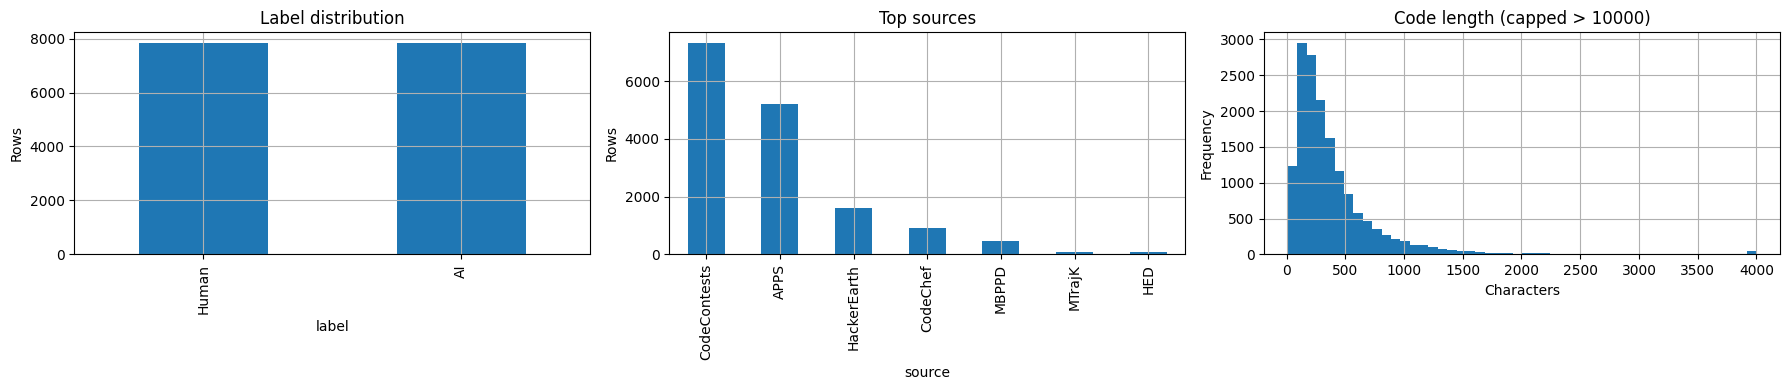

Saved: /kaggle/working/oedingen_lr_only_results/figures/eda_overview.png


In [39]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df["label"].map({0: "Human", 1: "AI"}).value_counts().reindex(["Human", "AI"]).plot(
    kind="bar", ax=axes[0], title="Label distribution"
)
axes[0].set_ylabel("Rows")

df["source"].value_counts().head(12).plot(kind="bar", ax=axes[1], title="Top sources")
axes[1].set_ylabel("Rows")

lengths = df["code"].astype(str).str.len()
lengths = lengths.apply(lambda x: 4001 if x > 4000 else x)
lengths.plot(kind="hist", bins=50, ax=axes[2], title="Code length (capped > 10000)")
axes[2].set_xlabel("Characters")

plt.tight_layout()
fig_path = FIGURE_DIR / "eda_overview.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

## 4. Lexical feature extraction

In [10]:

PY_KEYWORDS = set(keyword.kwlist)
TOKEN_RE = re.compile(r"[A-Za-z_][A-Za-z_0-9]*|\d+\.\d+|\d+|==|!=|<=|>=|&&|\|\||[-+*/%=<>()[\]{}.,:;#]")


def strip_python_comments_and_docstrings(code_text: str) -> str:
    out = []
    prev_toktype = tokenize.INDENT
    last_lineno = 1
    last_col = 0
    try:
        for tok_type, tok_string, start, end, _ in tokenize.generate_tokens(io.StringIO(str(code_text)).readline):
            sline, scol = start
            eline, ecol = end
            if sline > last_lineno:
                last_col = 0
            if scol > last_col:
                out.append(" " * (scol - last_col))
            if tok_type == tokenize.COMMENT:
                pass
            elif tok_type == tokenize.STRING and prev_toktype in {tokenize.INDENT, tokenize.NEWLINE, tokenize.DEDENT, tokenize.ENDMARKER}:
                pass
            else:
                out.append(tok_string)
            prev_toktype = tok_type
            last_col = ecol
            last_lineno = eline
        return "".join(out)
    except Exception:
        return re.sub(r"#.*", "", str(code_text))


def lexical_features(code_text: str) -> Dict[str, float]:
    text = str(code_text)
    lines = text.splitlines()
    nonempty = [ln for ln in lines if ln.strip()]
    tokens = TOKEN_RE.findall(text)
    identifiers = [t for t in tokens if re.match(r"^[A-Za-z_]", t)]
    keyword_count = sum(1 for t in identifiers if t in PY_KEYWORDS)
    comment_lines = sum(1 for ln in lines if ln.strip().startswith("#"))
    indent_lengths = [len(ln) - len(ln.lstrip(" ")) for ln in nonempty]
    stripped = strip_python_comments_and_docstrings(text)
    no_comment_tokens = TOKEN_RE.findall(stripped)
    operators = sum(1 for t in tokens if t in set("+-*/%=<>") or t in {"==", "!=", "<=", ">="})
    return {
        "char_len": float(len(text)),
        "line_count": float(len(lines)),
        "nonempty_line_count": float(len(nonempty)),
        "avg_line_len": float(np.mean([len(ln) for ln in lines])) if lines else 0.0,
        "max_line_len": float(max([len(ln) for ln in lines], default=0)),
        "token_count": float(len(tokens)),
        "unique_token_count": float(len(set(tokens))),
        "identifier_count": float(len(identifiers)),
        "keyword_count": float(keyword_count),
        "keyword_ratio": float(keyword_count / max(1, len(identifiers))),
        "comment_line_count": float(comment_lines),
        "comment_ratio": float(comment_lines / max(1, len(lines))),
        "avg_indent": float(np.mean(indent_lengths)) if indent_lengths else 0.0,
        "max_indent": float(max(indent_lengths, default=0)),
        "operator_count": float(operators),
        "no_comment_token_count": float(len(no_comment_tokens)),
        "blank_line_ratio": float((len(lines) - len(nonempty)) / max(1, len(lines))),
    }

lexical_cache = CACHE_DIR / "lexical_features.csv"
if lexical_cache.exists():
    lexical_df = pd.read_csv(lexical_cache)
    print("Loaded cached lexical features:", lexical_cache, lexical_df.shape)
else:
    lexical_df = pd.DataFrame([lexical_features(x) for x in tqdm(df["code"], desc="Lexical features")])
    lexical_df.to_csv(lexical_cache, index=False)
    print("Saved lexical features:", lexical_cache, lexical_df.shape)

length_cols = ["char_len", "line_count", "nonempty_line_count", "avg_line_len", "max_line_len", "token_count", "no_comment_token_count"]
no_length_cols = [c for c in lexical_df.columns if c not in length_cols]
print("Lexical columns:", len(lexical_df.columns))
print("No-length lexical columns:", len(no_length_cols))

Lexical features:   0%|          | 0/15679 [00:00<?, ?it/s]

Saved lexical features: /kaggle/working/oedingen_lr_only_results/cache/lexical_features.csv (15679, 17)
Lexical columns: 17
No-length lexical columns: 10


## 5. TDA feature extraction

In [11]:

def parse_python_snippet(code_text: str) -> Optional[ast.AST]:
    clean = str(code_text).strip("\n")
    try:
        return ast.parse(clean)
    except SyntaxError:
        wrapped = "def _snippet_wrapper():\n" + textwrap.indent(clean, "    ")
        try:
            return ast.parse(wrapped)
        except Exception:
            return None


def iter_ast_nodes_with_depth(tree: ast.AST) -> Iterable[Tuple[ast.AST, int]]:
    stack = [(tree, 0)]
    while stack:
        node, depth = stack.pop()
        yield node, depth
        children = list(ast.iter_child_nodes(node))
        for child in reversed(children):
            stack.append((child, depth + 1))


def ast_point_cloud(code_text: str, max_points: int = MAX_AST_POINTS) -> np.ndarray:
    '''Represent Python code as a small AST-derived point cloud.

    Dimensions:
      1) normalized depth;
      2) normalized child count;
      3) normalized line number;
      4) normalized node type hash.
    '''
    tree = parse_python_snippet(code_text)
    if tree is None:
        return np.array([[0.0, 0.0, 0.0, 0.0], [0.01, 0.0, 0.0, 0.0]], dtype=np.float32)

    rows = []
    for node, depth in iter_ast_nodes_with_depth(tree):
        children = list(ast.iter_child_nodes(node))
        lineno = float(getattr(node, "lineno", 0))
        node_type_hash = (abs(hash(type(node).__name__)) % 997) / 997.0
        rows.append([float(depth), float(len(children)), lineno, node_type_hash])

    if not rows:
        rows = [[0.0, 0.0, 0.0, 0.0]]
    cloud = np.array(rows[:max_points], dtype=np.float32)
    if len(cloud) == 1:
        cloud = np.vstack([cloud, cloud + 1e-3]).astype(np.float32)

    # Scale each coordinate to [0, 1] for stable distances.
    denom = cloud.max(axis=0) - cloud.min(axis=0)
    denom[denom == 0] = 1.0
    cloud = (cloud - cloud.min(axis=0)) / denom
    return cloud.astype(np.float32)


def persistence_diagram_for_code(code_text: str) -> Dict[int, np.ndarray]:
    cloud = ast_point_cloud(code_text)
    result = ripser(cloud, maxdim=max(TDA_HOMOLOGY_DIMS))
    return {dim: result["dgms"][dim] for dim in TDA_HOMOLOGY_DIMS}


def finite_lifetimes(diagram: np.ndarray) -> np.ndarray:
    if diagram is None or len(diagram) == 0:
        return np.array([], dtype=np.float32)
    dgm = np.asarray(diagram, dtype=np.float32)
    mask = np.isfinite(dgm[:, 1]) & np.isfinite(dgm[:, 0])
    lifetimes = dgm[mask, 1] - dgm[mask, 0]
    return lifetimes[lifetimes > 1e-8]


def entropy_from_lifetimes(lifetimes: np.ndarray) -> float:
    if lifetimes.size == 0:
        return 0.0
    probs = lifetimes / max(lifetimes.sum(), 1e-12)
    return float(-(probs * np.log(probs + 1e-12)).sum())


def diagram_summary(diagrams: Dict[int, np.ndarray]) -> Dict[str, float]:
    out = {}
    for dim in TDA_HOMOLOGY_DIMS:
        lifetimes = finite_lifetimes(diagrams.get(dim))
        prefix = f"tda_h{dim}"
        out[f"{prefix}_count"] = float(lifetimes.size)
        out[f"{prefix}_sum_persistence"] = float(lifetimes.sum()) if lifetimes.size else 0.0
        out[f"{prefix}_max_persistence"] = float(lifetimes.max()) if lifetimes.size else 0.0
        out[f"{prefix}_mean_persistence"] = float(lifetimes.mean()) if lifetimes.size else 0.0
        out[f"{prefix}_entropy"] = entropy_from_lifetimes(lifetimes)
    return out


def betti_curve(diagram: np.ndarray, grid: np.ndarray) -> np.ndarray:
    if diagram is None or len(diagram) == 0:
        return np.zeros(len(grid), dtype=np.float32)
    dgm = np.asarray(diagram, dtype=np.float32)
    births = dgm[:, 0]
    deaths = dgm[:, 1]
    finite = np.isfinite(deaths)
    births, deaths = births[finite], deaths[finite]
    vals = np.zeros(len(grid), dtype=np.float32)
    for i, t in enumerate(grid):
        vals[i] = np.sum((births <= t) & (deaths > t))
    return vals

In [12]:

import pickle

diagram_cache = CACHE_DIR / "tda_diagrams.pkl"
tda_summary_cache = CACHE_DIR / "tda_summary_features.csv"
tda_betti_cache = CACHE_DIR / "tda_betti_features.csv"

if diagram_cache.exists() and tda_summary_cache.exists() and tda_betti_cache.exists():
    with open(diagram_cache, "rb") as f:
        diagrams_list = pickle.load(f)
    tda_summary = pd.read_csv(tda_summary_cache)
    tda_betti = pd.read_csv(tda_betti_cache)
    print("Loaded cached TDA features:", tda_summary.shape, tda_betti.shape)
else:
    diagrams_list = [persistence_diagram_for_code(x) for x in tqdm(df["code"], desc="Persistence diagrams")]
    with open(diagram_cache, "wb") as f:
        pickle.dump(diagrams_list, f)

    tda_summary = pd.DataFrame([diagram_summary(dgm) for dgm in tqdm(diagrams_list, desc="TDA summaries")])
    tda_summary.to_csv(tda_summary_cache, index=False)

    # Global scale for Betti curves. The grid uses finite deaths only.
    finite_vals = []
    for dgm in diagrams_list:
        for dim in TDA_HOMOLOGY_DIMS:
            arr = dgm.get(dim)
            if arr is not None and len(arr):
                finite_vals.extend(arr[np.isfinite(arr[:, 1]), 1].tolist())
    max_death = float(np.percentile(finite_vals, 95)) if finite_vals else 1.0
    grid = np.linspace(0, max(max_death, 1e-3), BETTI_GRID)

    betti_rows = []
    for dgm in tqdm(diagrams_list, desc="Betti curves"):
        row = {}
        for dim in TDA_HOMOLOGY_DIMS:
            curve = betti_curve(dgm.get(dim), grid)
            for i, val in enumerate(curve):
                row[f"tda_betti_h{dim}_{i:02d}"] = float(val)
        betti_rows.append(row)
    tda_betti = pd.DataFrame(betti_rows)
    tda_betti.to_csv(tda_betti_cache, index=False)
    print("Saved TDA cache")

tda_all = pd.concat([tda_summary, tda_betti], axis=1)
tda_betti_h0_cols = [c for c in tda_betti.columns if "_h0_" in c]
tda_betti_h1_cols = [c for c in tda_betti.columns if "_h1_" in c]
print("TDA summary:", tda_summary.shape)
print("TDA betti:", tda_betti.shape)
print("TDA all:", tda_all.shape)

Persistence diagrams:   0%|          | 0/15679 [00:00<?, ?it/s]

TDA summaries:   0%|          | 0/15679 [00:00<?, ?it/s]

Betti curves:   0%|          | 0/15679 [00:00<?, ?it/s]

Saved TDA cache
TDA summary: (15679, 10)
TDA betti: (15679, 64)
TDA all: (15679, 74)


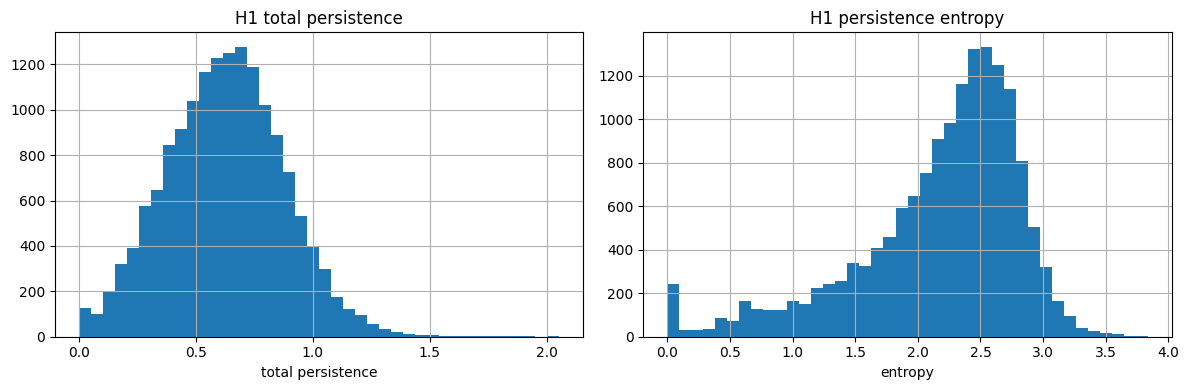

Saved: /kaggle/working/oedingen_lr_only_results/figures/tda_feature_distributions.png


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tda_summary.get("tda_h1_sum_persistence", pd.Series(np.zeros(len(df)))), bins=40)
axes[0].set_title("H1 total persistence")
axes[0].set_xlabel("total persistence")

axes[1].hist(tda_summary.get("tda_h1_entropy", pd.Series(np.zeros(len(df)))), bins=40)
axes[1].set_title("H1 persistence entropy")
axes[1].set_xlabel("entropy")

plt.tight_layout()
fig_path = FIGURE_DIR / "tda_feature_distributions.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

## 6. Feature blocks and configuration builder

In [14]:

feature_blocks: Dict[str, np.ndarray] = {
    "lexical_full": lexical_df.to_numpy(dtype=np.float32),
    "lexical_no_length": lexical_df[no_length_cols].to_numpy(dtype=np.float32),
    "tda_summary": tda_summary.to_numpy(dtype=np.float32),
    "tda_betti": tda_betti.to_numpy(dtype=np.float32),
    "tda_betti_h0": tda_betti[tda_betti_h0_cols].to_numpy(dtype=np.float32) if tda_betti_h0_cols else np.empty((len(df), 0), dtype=np.float32),
    "tda_betti_h1": tda_betti[tda_betti_h1_cols].to_numpy(dtype=np.float32) if tda_betti_h1_cols else np.empty((len(df), 0), dtype=np.float32),
    "tda_all": tda_all.to_numpy(dtype=np.float32),
}

for name, arr in available_embeddings.items():
    feature_blocks[name] = arr.astype(np.float32)


def combine_blocks(block_names: Sequence[str]) -> np.ndarray:
    arrays = [feature_blocks[name] for name in block_names]
    arrays = [arr for arr in arrays if arr.shape[1] > 0]
    if not arrays:
        raise ValueError("No feature blocks selected")
    return np.hstack(arrays).astype(np.float32)


@dataclass(frozen=True)
class Config:
    name: str
    blocks: Tuple[str, ...]
    model_type: str = "lr"
    family: str = ""
    ablation_context: str = ""


def make_lr(seed: int = RANDOM_SEED) -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, solver="lbfgs", random_state=seed)),
    ])


def make_model(config: Config, seed: int = RANDOM_SEED):
    return make_lr(seed)


def predict_proba_safe(model, X: np.ndarray) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    scores = model.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


def metric_dict(y_true: np.ndarray, prob: np.ndarray) -> Dict[str, float]:
    pred = (prob >= 0.5).astype(int)
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, pred),
        "brier": brier_score_loss(y_true, prob),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, prob)
    except Exception:
        out["roc_auc"] = np.nan
    try:
        out["pr_auc"] = average_precision_score(y_true, prob)
    except Exception:
        out["pr_auc"] = np.nan
    return out


def build_configs() -> List[Config]:
    configs: List[Config] = []
    configs.extend([
        Config("Lexical-full", ("lexical_full",), family="lexical"),
        Config("Lexical-no-length", ("lexical_no_length",), family="lexical"),
        Config("TDA-summary", ("tda_summary",), family="tda"),
        Config("TDA-all", ("tda_all",), family="tda"),
        Config("Lexical-full + TDA-summary", ("lexical_full", "tda_summary"), family="lexical_tda"),
        Config("Lexical-full + TDA-all", ("lexical_full", "tda_all"), family="lexical_tda"),
        Config("Lexical-no-length + TDA-summary", ("lexical_no_length", "tda_summary"), family="lexical_tda"),
        Config("Lexical-no-length + TDA-all", ("lexical_no_length", "tda_all"), family="lexical_tda"),
    ])

    for emb in available_embeddings:
        pretty = emb.upper() if emb == "ada" else {"sbert": "SBERT", "codebert": "CodeBERT", "graphcodebert": "GraphCodeBERT", "unixcoder": "UniXcoder"}.get(emb, emb)
        configs.extend([
            Config(f"{pretty}", (emb,), family=emb, ablation_context="embedding"),
            Config(f"{pretty} + Lexical", (emb, "lexical_full"), family=emb, ablation_context="embedding+lexical"),
            Config(f"{pretty} + TDA-summary", (emb, "tda_summary"), family=emb, ablation_context="embedding+tda_summary"),
            Config(f"{pretty} + TDA-all", (emb, "tda_all"), family=emb, ablation_context="embedding+tda_all"),
            Config(f"{pretty} + Lexical + TDA-summary", (emb, "lexical_full", "tda_summary"), family=emb, ablation_context="embedding+lexical+tda_summary"),
            Config(f"{pretty} + Lexical + TDA-all", (emb, "lexical_full", "tda_all"), family=emb, ablation_context="embedding+lexical+tda_all"),
        ])
    return configs

configs = build_configs()
print("Number of LR-only configurations:", len(configs))
for cfg in configs:
    print(f"- {cfg.name}: {cfg.blocks}")


Number of LR-only configurations: 38
- Lexical-full: ('lexical_full',)
- Lexical-no-length: ('lexical_no_length',)
- TDA-summary: ('tda_summary',)
- TDA-all: ('tda_all',)
- Lexical-full + TDA-summary: ('lexical_full', 'tda_summary')
- Lexical-full + TDA-all: ('lexical_full', 'tda_all')
- Lexical-no-length + TDA-summary: ('lexical_no_length', 'tda_summary')
- Lexical-no-length + TDA-all: ('lexical_no_length', 'tda_all')
- ADA: ('ada',)
- ADA + Lexical: ('ada', 'lexical_full')
- ADA + TDA-summary: ('ada', 'tda_summary')
- ADA + TDA-all: ('ada', 'tda_all')
- ADA + Lexical + TDA-summary: ('ada', 'lexical_full', 'tda_summary')
- ADA + Lexical + TDA-all: ('ada', 'lexical_full', 'tda_all')
- SBERT: ('sbert',)
- SBERT + Lexical: ('sbert', 'lexical_full')
- SBERT + TDA-summary: ('sbert', 'tda_summary')
- SBERT + TDA-all: ('sbert', 'tda_all')
- SBERT + Lexical + TDA-summary: ('sbert', 'lexical_full', 'tda_summary')
- SBERT + Lexical + TDA-all: ('sbert', 'lexical_full', 'tda_all')
- CodeBERT: ('c

## 7. Group-aware train/validation/test split

In [15]:

gss_outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
train_val_idx, test_idx = next(gss_outer.split(df, labels, groups=groups))

relative_val_size = VAL_SIZE / (1.0 - TEST_SIZE)
gss_inner = GroupShuffleSplit(n_splits=1, test_size=relative_val_size, random_state=RANDOM_SEED + 1)
rel_train_idx, rel_val_idx = next(gss_inner.split(df.iloc[train_val_idx], labels[train_val_idx], groups=groups[train_val_idx]))
train_idx = train_val_idx[rel_train_idx]
val_idx = train_val_idx[rel_val_idx]

split_info = {
    "train_rows": int(len(train_idx)),
    "validation_rows": int(len(val_idx)),
    "test_rows": int(len(test_idx)),
    "train_groups": int(len(np.unique(groups[train_idx]))),
    "validation_groups": int(len(np.unique(groups[val_idx]))),
    "test_groups": int(len(np.unique(groups[test_idx]))),
    "random_seed": RANDOM_SEED,
    "test_size": TEST_SIZE,
    "val_size": VAL_SIZE,
}
(OUTPUT_DIR / "split_info.json").write_text(json.dumps(split_info, indent=2), encoding="utf-8")
print(split_info)
print("train labels", Counter(labels[train_idx]))
print("val labels", Counter(labels[val_idx]))
print("test labels", Counter(labels[test_idx]))

{'train_rows': 11291, 'validation_rows': 2116, 'test_rows': 2272, 'train_groups': 1750, 'validation_groups': 375, 'test_groups': 375, 'random_seed': 42, 'test_size': 0.15, 'val_size': 0.15}
train labels Counter({np.int64(1): 5646, np.int64(0): 5645})
val labels Counter({np.int64(1): 1058, np.int64(0): 1058})
test labels Counter({np.int64(1): 1136, np.int64(0): 1136})


## 8. Validation over all configurations

In [16]:

def fit_and_score_config(config: Config, train_idx: np.ndarray, eval_idx: np.ndarray, seed: int = RANDOM_SEED):
    X = combine_blocks(config.blocks)
    model = make_model(config, seed=seed)
    model.fit(X[train_idx], labels[train_idx])
    prob = predict_proba_safe(model, X[eval_idx])
    metrics = metric_dict(labels[eval_idx], prob)
    return model, prob, metrics

validation_rows = []
validation_predictions: Dict[str, np.ndarray] = {}
validation_models = {}

for cfg in tqdm(configs, desc="Validation configs"):
    model, prob, metrics = fit_and_score_config(cfg, train_idx, val_idx, seed=RANDOM_SEED)
    row = {"config": cfg.name, "blocks": "+".join(cfg.blocks), "model_type": cfg.model_type, "family": cfg.family, **metrics}
    validation_rows.append(row)
    validation_predictions[cfg.name] = prob
    validation_models[cfg.name] = model

validation_results = pd.DataFrame(validation_rows).sort_values(["f1", "roc_auc"], ascending=False)
validation_results.to_csv(TABLE_DIR / "validation_results_all_configs.csv", index=False)
validation_results.head(20)

Validation configs:   0%|          | 0/38 [00:00<?, ?it/s]

,config,blocks,model_type,family,accuracy,precision,recall,f1,mcc,brier,roc_auc,pr_auc
9,ADA + Lexical,ada+lexical_full,lr,ada,0.972117,0.969014,0.975425,0.972209,0.944255,0.024057,0.994642,0.993654
12,ADA + Lexical + TDA-summary,ada+lexical_full+tda_summary,lr,ada,0.971172,0.968956,0.973535,0.971240,0.942355,0.024419,0.994599,0.993551
13,ADA + Lexical + TDA-all,ada+lexical_full+tda_all,lr,ada,0.970699,0.967167,0.974480,0.970810,0.941426,0.025196,0.994156,0.992654
8,ADA,ada,lr,ada,0.968336,0.964386,0.972590,0.968471,0.936707,0.025622,0.994612,0.993508
10,ADA + TDA-summary,ada+tda_summary,lr,ada,0.967864,0.963483,0.972590,0.968015,0.935770,0.025629,0.994626,0.993446
27,GraphCodeBERT + Lexical,graphcodebert+lexical_full,lr,graphcodebert,0.966446,0.959070,0.974480,0.966714,0.933013,0.028744,0.991902,0.990499
11,ADA + TDA-all,ada+tda_all,lr,ada,0.966446,0.963380,0.969754,0.966557,0.932913,0.026479,0.994279,0.992717
30,GraphCodeBERT + Lexical + TDA-summary,graphcodebert+lexical_full+tda_summary,lr,graphcodebert,0.965974,0.957328,0.975425,0.966292,0.932114,0.029213,0.992146,0.991037
24,CodeBERT + Lexical + TDA-summary,codebert+lexical_full+tda_summary,lr,codebert,0.965501,0.957289,0.974480,0.965808,0.931152,0.029447,0.991263,0.989777
21,CodeBERT + Lexical,codebert+lexical_full,lr,codebert,0.964083,0.954630,0.974480,0.964453,0.928367,0.029693,0.991304,0.989898


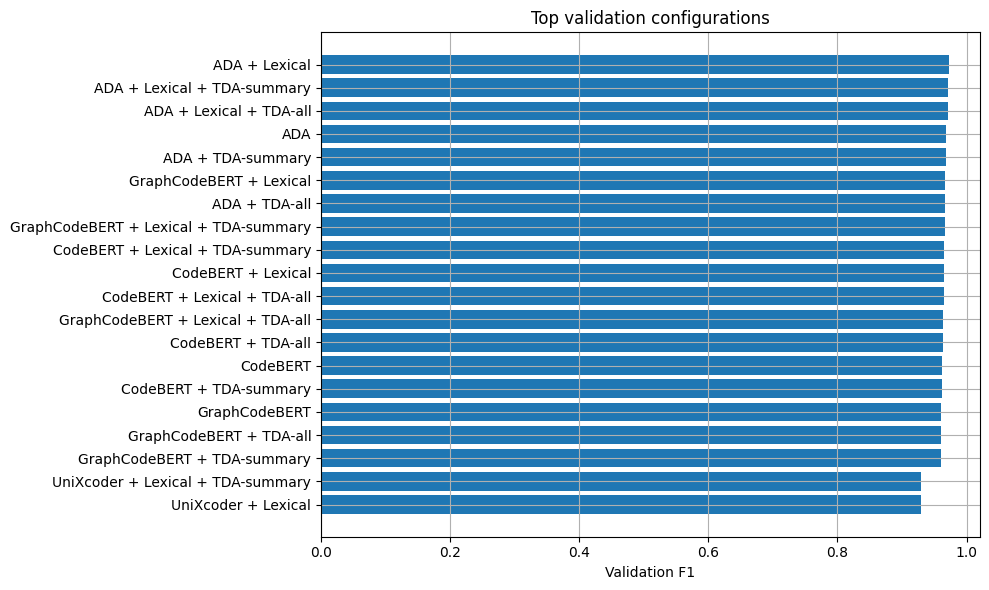

Saved: /kaggle/working/oedingen_lr_only_results/figures/top_validation_configurations_all.png


In [17]:

plt.figure(figsize=(10, max(5, len(validation_results.head(20)) * 0.3)))
top_val = validation_results.head(20).iloc[::-1]
plt.barh(top_val["config"], top_val["f1"])
plt.xlabel("Validation F1")
plt.title("Top validation configurations")
plt.tight_layout()
fig_path = FIGURE_DIR / "top_validation_configurations_all.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

## 9. Final test for all configurations

In [18]:

# Test is evaluated only after validation has finished. We train on train+validation and test on held-out groups.
train_full_idx = np.concatenate([train_idx, val_idx])

if RUN_ALL_FINAL_CONFIGS:
    final_configs = configs
else:
    selected = set(validation_results.head(10)["config"])
    final_configs = [cfg for cfg in configs if cfg.name in selected]

final_rows = []
test_predictions: Dict[str, np.ndarray] = {}
test_models = {}

for cfg in tqdm(final_configs, desc="Final test configs"):
    model, prob, metrics = fit_and_score_config(cfg, train_full_idx, test_idx, seed=RANDOM_SEED)
    row = {"config": cfg.name, "blocks": "+".join(cfg.blocks), "model_type": cfg.model_type, "family": cfg.family, **metrics}
    final_rows.append(row)
    test_predictions[cfg.name] = prob
    test_models[cfg.name] = model

test_results = pd.DataFrame(final_rows).sort_values(["f1", "roc_auc"], ascending=False)
test_results.to_csv(TABLE_DIR / "test_results_all_configs.csv", index=False)
test_results.head(25)

Final test configs:   0%|          | 0/38 [00:00<?, ?it/s]

,config,blocks,model_type,family,accuracy,precision,recall,f1,mcc,brier,roc_auc,pr_auc
9,ADA + Lexical,ada+lexical_full,lr,ada,0.974032,0.976971,0.970951,0.973951,0.948081,0.023155,0.995797,0.995564
12,ADA + Lexical + TDA-summary,ada+lexical_full+tda_summary,lr,ada,0.973592,0.975265,0.971831,0.973545,0.947189,0.023531,0.995768,0.995495
10,ADA + TDA-summary,ada+tda_summary,lr,ada,0.970511,0.971756,0.969190,0.970472,0.941024,0.024645,0.995481,0.995373
13,ADA + Lexical + TDA-all,ada+lexical_full+tda_all,lr,ada,0.970070,0.970899,0.969190,0.970044,0.940142,0.024601,0.995551,0.995419
8,ADA,ada,lr,ada,0.969190,0.970848,0.967430,0.969136,0.938386,0.026056,0.995440,0.995318
30,GraphCodeBERT + Lexical + TDA-summary,graphcodebert+lexical_full+tda_summary,lr,graphcodebert,0.968310,0.969965,0.966549,0.968254,0.936626,0.026603,0.993852,0.992439
28,GraphCodeBERT + TDA-summary,graphcodebert+tda_summary,lr,graphcodebert,0.968310,0.969965,0.966549,0.968254,0.936626,0.026780,0.993413,0.991450
11,ADA + TDA-all,ada+tda_all,lr,ada,0.968310,0.970796,0.965669,0.968226,0.936633,0.026124,0.995224,0.995145
25,CodeBERT + Lexical + TDA-all,codebert+lexical_full+tda_all,lr,codebert,0.967430,0.968254,0.966549,0.967401,0.934861,0.026615,0.993131,0.993298
31,GraphCodeBERT + Lexical + TDA-all,graphcodebert+lexical_full+tda_all,lr,graphcodebert,0.967430,0.969912,0.964789,0.967343,0.934872,0.027384,0.993648,0.992048


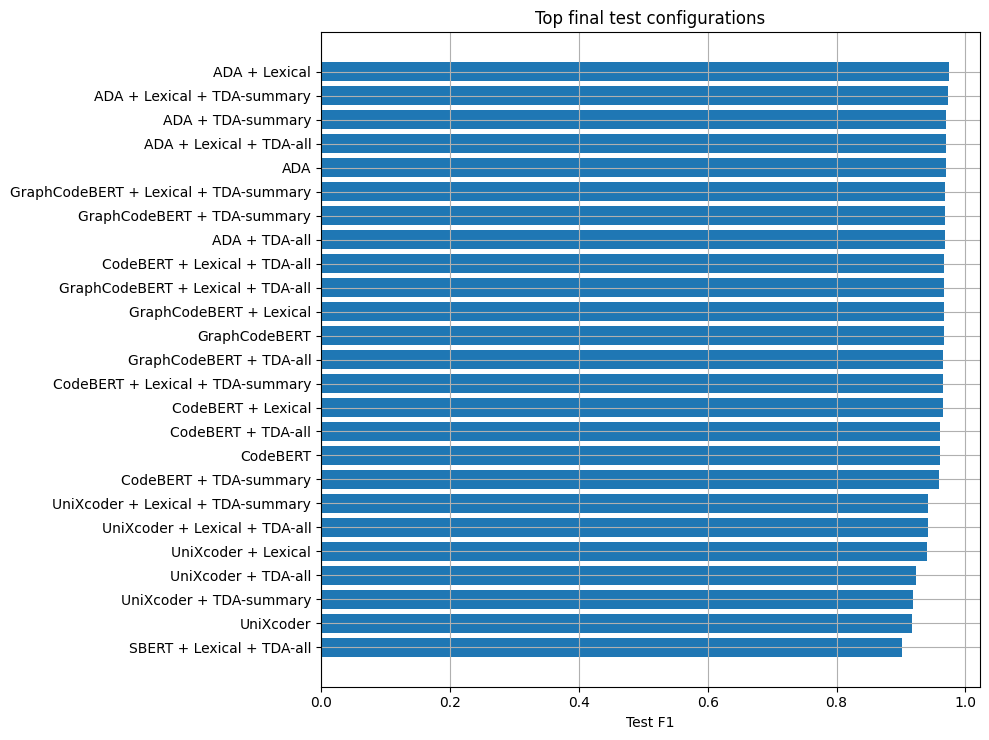

Saved: /kaggle/working/oedingen_lr_only_results/figures/top_test_configurations_all.png


In [19]:

plt.figure(figsize=(10, max(5, len(test_results.head(25)) * 0.3)))
top_test = test_results.head(25).iloc[::-1]
plt.barh(top_test["config"], top_test["f1"])
plt.xlabel("Test F1")
plt.title("Top final test configurations")
plt.tight_layout()
fig_path = FIGURE_DIR / "top_test_configurations_all.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

## 10. Paired A/B analysis: did TDA itself help?

In [20]:

def exact_mcnemar_p(n01: int, n10: int) -> float:
    '''Two-sided exact McNemar/binomial test. n01: A wrong, B correct. n10: A correct, B wrong.'''
    n = n01 + n10
    if n == 0:
        return 1.0
    if binomtest is not None:
        return float(binomtest(min(n01, n10), n=n, p=0.5, alternative="two-sided").pvalue)
    # Fallback exact two-sided binomial probability.
    from math import comb
    k = min(n01, n10)
    prob = sum(comb(n, i) * (0.5 ** n) for i in range(0, k + 1)) * 2
    return float(min(1.0, prob))


def paired_comparison(config_a: str, config_b: str) -> Dict[str, object]:
    prob_a = test_predictions[config_a]
    prob_b = test_predictions[config_b]
    y = labels[test_idx]
    pred_a = (prob_a >= 0.5).astype(int)
    pred_b = (prob_b >= 0.5).astype(int)
    correct_a = pred_a == y
    correct_b = pred_b == y
    n01 = int((~correct_a & correct_b).sum())  # B rescued A
    n10 = int((correct_a & ~correct_b).sum())  # B harmed A
    m_a = metric_dict(y, prob_a)
    m_b = metric_dict(y, prob_b)
    return {
        "A_config": config_a,
        "B_config": config_b,
        "A_f1": m_a["f1"],
        "B_f1": m_b["f1"],
        "delta_f1_B_minus_A": m_b["f1"] - m_a["f1"],
        "A_roc_auc": m_a["roc_auc"],
        "B_roc_auc": m_b["roc_auc"],
        "delta_roc_auc_B_minus_A": m_b["roc_auc"] - m_a["roc_auc"],
        "A_mcc": m_a["mcc"],
        "B_mcc": m_b["mcc"],
        "delta_mcc_B_minus_A": m_b["mcc"] - m_a["mcc"],
        "rescued_by_B": n01,
        "harmed_by_B": n10,
        "mcnemar_p": exact_mcnemar_p(n01, n10),
    }

# Construct minimal-change pairs: same embedding, same classifier, same split, only TDA added.
name_lookup = {cfg.name: cfg for cfg in configs}
pair_rows = []

pretty_by_emb = {"ada": "ADA", "sbert": "SBERT", "codebert": "CodeBERT", "graphcodebert": "GraphCodeBERT", "unixcoder": "UniXcoder"}
for emb in available_embeddings:
    pretty = pretty_by_emb.get(emb, emb)
    candidate_pairs = [
        (f"{pretty}", f"{pretty} + TDA-summary"),
        (f"{pretty}", f"{pretty} + TDA-all"),
        (f"{pretty} + Lexical", f"{pretty} + Lexical + TDA-summary"),
        (f"{pretty} + Lexical", f"{pretty} + Lexical + TDA-all"),
    ]
    for a, b in candidate_pairs:
        if a in test_predictions and b in test_predictions:
            row = paired_comparison(a, b)
            row["embedding_family"] = pretty
            pair_rows.append(row)

pairwise_tda = pd.DataFrame(pair_rows).sort_values(["embedding_family", "delta_f1_B_minus_A"])
pairwise_tda.to_csv(TABLE_DIR / "paired_tda_ablation_results.csv", index=False)
pairwise_tda

,A_config,B_config,A_f1,B_f1,delta_f1_B_minus_A,A_roc_auc,B_roc_auc,delta_roc_auc_B_minus_A,A_mcc,B_mcc,delta_mcc_B_minus_A,rescued_by_B,harmed_by_B,mcnemar_p,embedding_family
3,ADA + Lexical,ADA + Lexical + TDA-all,0.973951,0.970044,-0.003907,0.995797,0.995551,-0.000246,0.948081,0.940142,-0.007939,5,14,0.063568,ADA
1,ADA,ADA + TDA-all,0.969136,0.968226,-0.000910,0.995440,0.995224,-0.000216,0.938386,0.936633,-0.001753,10,12,0.831812,ADA
2,ADA + Lexical,ADA + Lexical + TDA-summary,0.973951,0.973545,-0.000406,0.995797,0.995768,-0.000029,0.948081,0.947189,-0.000892,3,4,1.000000,ADA
0,ADA,ADA + TDA-summary,0.969136,0.970472,0.001336,0.995440,0.995481,0.000041,0.938386,0.941024,0.002638,6,3,0.507812,ADA
8,CodeBERT,CodeBERT + TDA-summary,0.960637,0.959328,-0.001309,0.992138,0.992190,0.000052,0.921698,0.919050,-0.002648,2,5,0.453125,CodeBERT
10,CodeBERT + Lexical,CodeBERT + Lexical + TDA-summary,0.965029,0.965029,0.000000,0.993077,0.993099,0.000022,0.930519,0.930519,0.000000,4,4,1.000000,CodeBERT
9,CodeBERT,CodeBERT + TDA-all,0.960637,0.960776,0.000139,0.992138,0.992104,-0.000034,0.921698,0.921658,-0.000040,12,12,1.000000,CodeBERT
11,CodeBERT + Lexical,CodeBERT + Lexical + TDA-all,0.965029,0.967401,0.002372,0.993077,0.993131,0.000053,0.930519,0.934861,0.004342,16,11,0.442068,CodeBERT
13,GraphCodeBERT,GraphCodeBERT + TDA-all,0.966887,0.965487,-0.001401,0.993654,0.993253,-0.000401,0.933997,0.931390,-0.002607,13,16,0.711071,GraphCodeBERT
15,GraphCodeBERT + Lexical,GraphCodeBERT + Lexical + TDA-all,0.966946,0.967343,0.000398,0.994013,0.993648,-0.000365,0.933982,0.934872,0.000890,9,8,1.000000,GraphCodeBERT


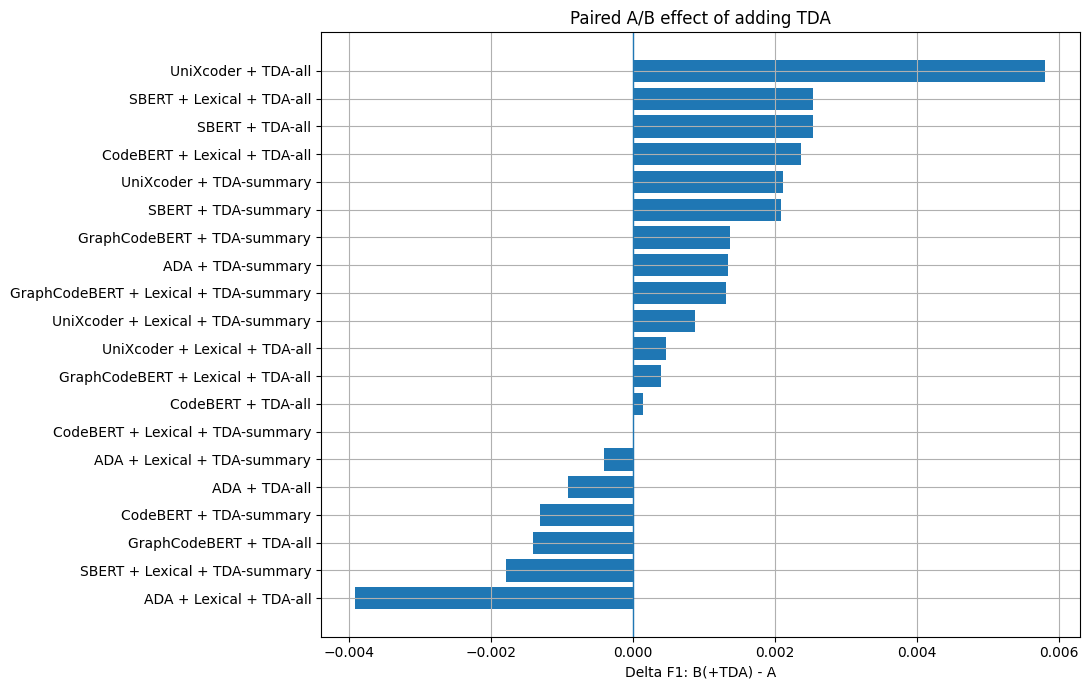

Saved: /kaggle/working/oedingen_lr_only_results/figures/paired_tda_ablation_delta_f1.png


In [21]:

if len(pairwise_tda):
    plot_df = pairwise_tda.copy()
    plot_df["pair"] = plot_df["embedding_family"] + " -> +TDA"
    plt.figure(figsize=(11, max(5, 0.35 * len(plot_df))))
    ordered = plot_df.sort_values("delta_f1_B_minus_A")
    plt.barh(ordered["B_config"], ordered["delta_f1_B_minus_A"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Delta F1: B(+TDA) - A")
    plt.title("Paired A/B effect of adding TDA")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "paired_tda_ablation_delta_f1.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

## 11. TDA feature-volume experiment

In [22]:

# This isolates the question: what happens as more TDA information is added?
# The classifier and split stay fixed. Only the TDA block changes.
TDA_VOLUME_BLOCKS = [
    ("no_tda", tuple()),
    ("tda_summary", ("tda_summary",)),
    ("tda_summary_plus_h0_betti", ("tda_summary", "tda_betti_h0")),
    ("tda_summary_plus_h1_betti", ("tda_summary", "tda_betti_h1")),
    ("tda_all", ("tda_all",)),
]

volume_rows = []
for emb in tqdm(list(available_embeddings), desc="TDA volume by embedding"):
    pretty = pretty_by_emb.get(emb, emb)
    for lexical_mode, lexical_blocks in [("embedding_only", tuple()), ("embedding_plus_lexical", ("lexical_full",))]:
        for tda_name, tda_blocks in TDA_VOLUME_BLOCKS:
            blocks = tuple([emb]) + lexical_blocks + tda_blocks
            config = Config(f"{pretty} + {lexical_mode} + {tda_name}", blocks, "lr", family=emb)
            model, prob, metrics = fit_and_score_config(config, train_full_idx, test_idx, seed=RANDOM_SEED)
            volume_rows.append({
                "embedding_family": pretty,
                "lexical_mode": lexical_mode,
                "tda_volume": tda_name,
                "n_features_total": int(sum(feature_blocks[b].shape[1] for b in blocks)),
                "n_embedding_features": int(feature_blocks[emb].shape[1]),
                "n_lexical_features": int(sum(feature_blocks[b].shape[1] for b in lexical_blocks)),
                "n_tda_features": int(sum(feature_blocks[b].shape[1] for b in tda_blocks)),
                **metrics,
            })

tda_volume_results = pd.DataFrame(volume_rows)
baseline = (
    tda_volume_results[tda_volume_results["tda_volume"] == "no_tda"]
    [["embedding_family", "lexical_mode", "f1"]]
    .rename(columns={"f1": "baseline_f1"})
)
tda_volume_results = tda_volume_results.merge(baseline, on=["embedding_family", "lexical_mode"], how="left")
tda_volume_results["delta_f1"] = tda_volume_results["f1"] - tda_volume_results["baseline_f1"]
tda_volume_results.to_csv(TABLE_DIR / "tda_feature_volume_results.csv", index=False)
tda_volume_results.to_csv(TABLE_DIR / "tda_feature_volume_results_with_delta.csv", index=False)

tda_counts_table = pd.DataFrame([
    {
        "tda_volume": name,
        "n_tda_features": int(sum(feature_blocks[b].shape[1] for b in blocks)),
        "blocks": ", ".join(blocks) if blocks else "none",
    }
    for name, blocks in TDA_VOLUME_BLOCKS
])
tda_counts_table.to_csv(TABLE_DIR / "tda_feature_counts.csv", index=False)

display(tda_counts_table)
display(tda_volume_results.sort_values(["lexical_mode", "embedding_family", "n_tda_features"]))


TDA volume by embedding:   0%|          | 0/5 [00:00<?, ?it/s]

,tda_volume,n_tda_features,blocks
0,no_tda,0,none
1,tda_summary,10,tda_summary
2,tda_summary_plus_h0_betti,42,"tda_summary, tda_betti_h0"
3,tda_summary_plus_h1_betti,42,"tda_summary, tda_betti_h1"
4,tda_all,74,tda_all


,embedding_family,lexical_mode,tda_volume,n_features_total,n_embedding_features,n_lexical_features,n_tda_features,accuracy,precision,recall,f1,mcc,brier,roc_auc,pr_auc,baseline_f1,delta_f1
0,ADA,embedding_only,no_tda,1536,1536,0,0,0.969190,0.970848,0.967430,0.969136,0.938386,0.026056,0.995440,0.995318,0.969136,0.000000
1,ADA,embedding_only,tda_summary,1546,1536,0,10,0.970511,0.971756,0.969190,0.970472,0.941024,0.024645,0.995481,0.995373,0.969136,0.001336
2,ADA,embedding_only,tda_summary_plus_h0_betti,1578,1536,0,42,0.969190,0.970018,0.968310,0.969163,0.938382,0.024424,0.995696,0.995573,0.969136,0.000027
3,ADA,embedding_only,tda_summary_plus_h1_betti,1578,1536,0,42,0.969630,0.971706,0.967430,0.969563,0.939270,0.025545,0.995182,0.995109,0.969136,0.000427
4,ADA,embedding_only,tda_all,1610,1536,0,74,0.968310,0.970796,0.965669,0.968226,0.936633,0.026124,0.995224,0.995145,0.969136,-0.000910
20,CodeBERT,embedding_only,no_tda,768,768,0,0,0.960827,0.965333,0.955986,0.960637,0.921698,0.030688,0.992138,0.992163,0.960637,0.000000
21,CodeBERT,embedding_only,tda_summary,778,768,0,10,0.959507,0.963588,0.955106,0.959328,0.919050,0.030483,0.992190,0.992205,0.960637,-0.001309
22,CodeBERT,embedding_only,tda_summary_plus_h0_betti,810,768,0,42,0.963028,0.964664,0.961268,0.962963,0.926062,0.029402,0.992473,0.992413,0.960637,0.002326
23,CodeBERT,embedding_only,tda_summary_plus_h1_betti,810,768,0,42,0.960387,0.960387,0.960387,0.960387,0.920775,0.031102,0.991792,0.991884,0.960637,-0.000250
24,CodeBERT,embedding_only,tda_all,842,768,0,74,0.960827,0.962048,0.959507,0.960776,0.921658,0.030375,0.992104,0.992189,0.960637,0.000139


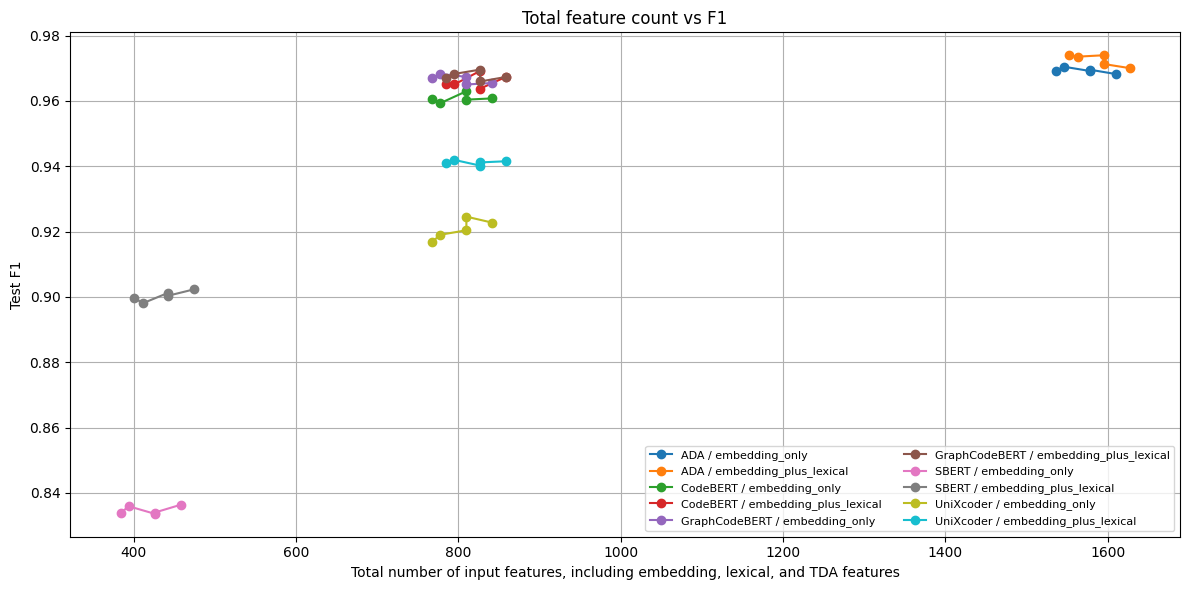

Saved: /kaggle/working/oedingen_lr_only_results/figures/feature_count_total_vs_f1.png


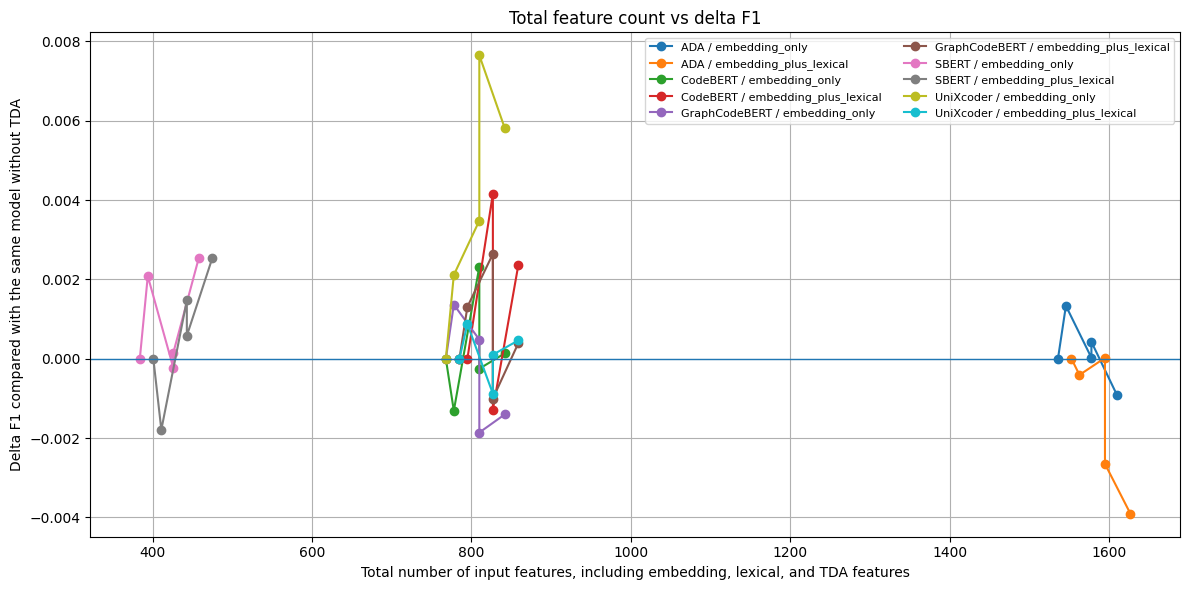

Saved: /kaggle/working/oedingen_lr_only_results/figures/feature_count_total_vs_delta_f1.png


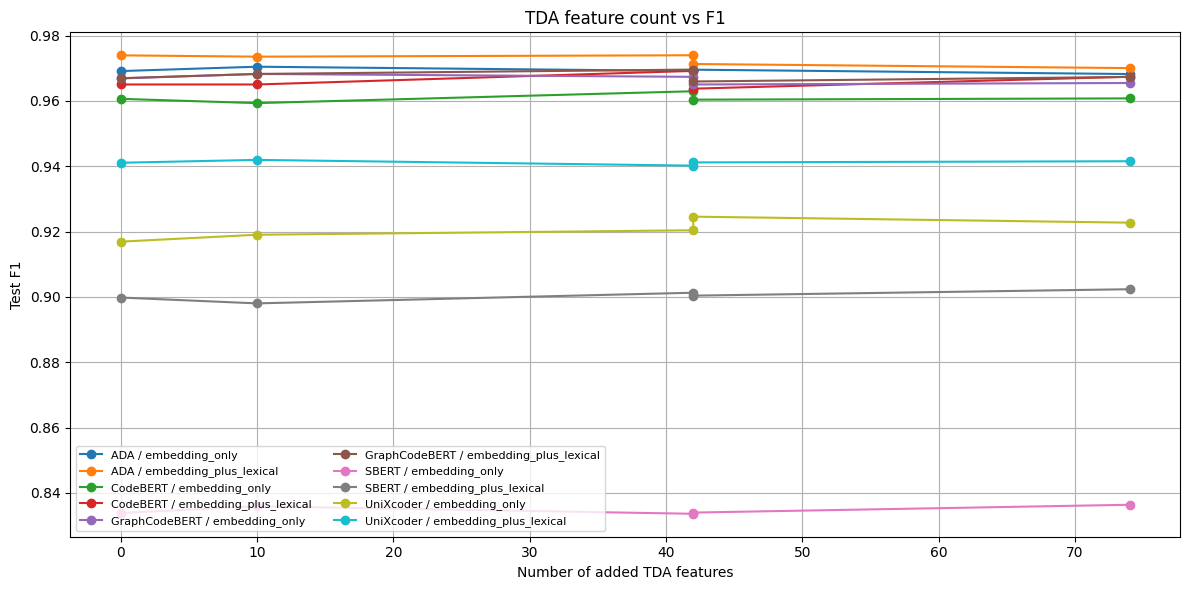

Saved: /kaggle/working/oedingen_lr_only_results/figures/feature_count_tda_vs_f1.png


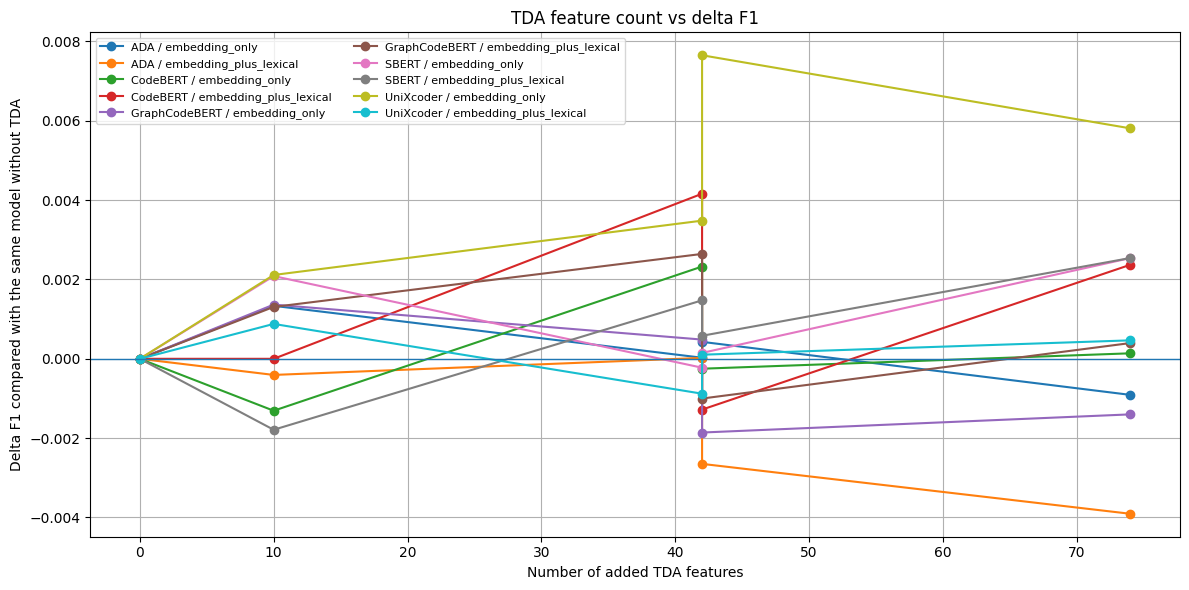

Saved: /kaggle/working/oedingen_lr_only_results/figures/feature_count_tda_vs_delta_f1.png


In [23]:

# Four feature-count plots:
# 1) total feature count -> F1
# 2) total feature count -> delta F1
# 3) added TDA feature count -> F1
# 4) added TDA feature count -> delta F1
# Each plot contains both modes: embedding-only and embedding + lexical.

def plot_volume_metric(x_col, y_col, title, x_label, y_label, filename):
    plt.figure(figsize=(12, 6))
    for (emb, lexical_mode), sub in tda_volume_results.groupby(["embedding_family", "lexical_mode"]):
        s = sub.sort_values([x_col, "tda_volume"])
        label = f"{emb} / {lexical_mode}"
        plt.plot(s[x_col], s[y_col], marker="o", label=label)
    if y_col == "delta_f1":
        plt.axhline(0, linewidth=1)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    fig_path = FIGURE_DIR / filename
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

plot_volume_metric(
    "n_features_total",
    "f1",
    "Total feature count vs F1",
    "Total number of input features, including embedding, lexical, and TDA features",
    "Test F1",
    "feature_count_total_vs_f1.png",
)

plot_volume_metric(
    "n_features_total",
    "delta_f1",
    "Total feature count vs delta F1",
    "Total number of input features, including embedding, lexical, and TDA features",
    "Delta F1 compared with the same model without TDA",
    "feature_count_total_vs_delta_f1.png",
)

plot_volume_metric(
    "n_tda_features",
    "f1",
    "TDA feature count vs F1",
    "Number of added TDA features",
    "Test F1",
    "feature_count_tda_vs_f1.png",
)

plot_volume_metric(
    "n_tda_features",
    "delta_f1",
    "TDA feature count vs delta F1",
    "Number of added TDA features",
    "Delta F1 compared with the same model without TDA",
    "feature_count_tda_vs_delta_f1.png",
)


## 12. Hard-case rescue analysis

In [24]:

def hard_case_table(config_a: str, config_b: str, max_rows: Optional[int] = None) -> pd.DataFrame:
    prob_a = test_predictions[config_a]
    prob_b = test_predictions[config_b]
    y = labels[test_idx]
    pred_a = (prob_a >= 0.5).astype(int)
    pred_b = (prob_b >= 0.5).astype(int)
    correct_a = pred_a == y
    correct_b = pred_b == y
    subset = df.iloc[test_idx].copy().reset_index(drop=False).rename(columns={"index": "row_index"})
    subset["true_label"] = y
    subset["A_config"] = config_a
    subset["B_config"] = config_b
    subset["A_prob_ai"] = prob_a
    subset["B_prob_ai"] = prob_b
    subset["A_pred"] = pred_a
    subset["B_pred"] = pred_b
    subset["A_margin"] = np.abs(prob_a - 0.5)
    subset["B_margin"] = np.abs(prob_b - 0.5)
    subset["case_type"] = np.select(
        [~correct_a & correct_b, correct_a & ~correct_b, ~correct_a & ~correct_b, correct_a & correct_b],
        ["rescued_by_TDA", "harmed_by_TDA", "both_wrong", "both_correct"],
        default="unknown",
    )
    subset["code_len"] = subset["code"].astype(str).str.len()
    # Add interpretable TDA summaries for inspection.
    for col in ["tda_h0_count", "tda_h0_sum_persistence", "tda_h1_count", "tda_h1_sum_persistence", "tda_h1_entropy"]:
        if col in tda_summary.columns:
            subset[col] = tda_summary.iloc[test_idx][col].to_numpy()
    if max_rows:
        return subset.head(max_rows)
    return subset

# Pick the best minimal TDA pair by F1 delta; if all deltas are negative, still use the least harmful pair.
if len(pairwise_tda):
    best_pair = pairwise_tda.sort_values("delta_f1_B_minus_A", ascending=False).iloc[0]
    config_a = str(best_pair["A_config"])
    config_b = str(best_pair["B_config"])
    print("Selected hard-case pair:", config_a, "vs", config_b)
    hard_cases = hard_case_table(config_a, config_b)
    hard_cases.to_csv(TABLE_DIR / "hard_case_rescue_analysis.csv", index=False)
    hard_summary = hard_cases.groupby(["case_type", "source", "true_label"]).size().reset_index(name="n").sort_values("n", ascending=False)
    hard_summary.to_csv(TABLE_DIR / "hard_case_rescue_summary_by_source_label.csv", index=False)
    display(hard_summary.head(30))
    display(hard_cases[hard_cases["case_type"].isin(["rescued_by_TDA", "harmed_by_TDA", "both_wrong"])].head(20))
else:
    print("No paired TDA comparisons available.")

Selected hard-case pair: UniXcoder vs UniXcoder + TDA-all


,case_type,source,true_label,n
4,both_correct,CodeContests,0,546
5,both_correct,CodeContests,1,546
0,both_correct,APPS,0,353
1,both_correct,APPS,1,328
3,both_correct,CodeChef,1,59
8,both_correct,HackerEarth,0,58
2,both_correct,CodeChef,0,56
9,both_correct,HackerEarth,1,56
15,both_wrong,APPS,1,47
18,both_wrong,CodeContests,0,29


,row_index,id,source,code,label,embedding,row_id_original,exact_signature,whitespace_signature,commentless_signature,...,B_pred,A_margin,B_margin,case_type,code_len,tda_h0_count,tda_h0_sum_persistence,tda_h1_count,tda_h1_sum_persistence,tda_h1_entropy
23,185,CodeContests_p02702 AtCoder Beginner Contest 1...,CodeContests,s = input()\n\nn = len(s)\n\ncount = 0\n\nfor ...,1,"[0.0270207636, -0.0024316753, -0.0099136299, -...",30204,efdb2e115c94a7167f3afb11da088b4c2256577857e81f...,24cd829c0c3b1db93521a4703ebd3a0cd3b0386581564e...,524e72c0fbe2b83ed920e431048ee5ac01549a5e9df4dc...,...,0,0.335101,0.196955,both_wrong,157,51.0,10.769407,8.0,0.414648,1.667994
29,221,APPS_6332,APPS,"c = list(map(int, input().split()))\ns = sum(c...",1,"[0.0283073951, -0.0027391529, 0.0051437267, 0....",11488,991d787d8b78b6adacc0d3e5c6bf2e2fef8d0aba94f161...,9d4bac02e31335a0460f0fb5b4f2e370502145a73b70bf...,f76b7ca30b52a22643a6e53d58ed5adb274d6ad254883c...,...,0,0.357148,0.436454,both_wrong,110,44.0,11.347610,12.0,0.646966,2.206872
39,329,CodeContests_p03149 KEYENCE Programming Contes...,CodeContests,"A=[1,4,7,9]\nif sorted(list(map(int,input().sp...",0,"[0.0069152322, -0.0159030408, -0.0187461916, -...",23995,f23dedee1fd49986af4a4c6c487064e2c5ab5c44b45782...,e2d007f83444b273991d14fc442031bbea8ce4b2475204...,cc1e98e69cf39f0c016bbf2bc03d2fe59ccb1aa7c632c2...,...,1,0.426559,0.468065,both_wrong,92,34.0,8.500515,7.0,0.414075,1.599693
41,346,CodeChef_TRICOIN,CodeChef,cases = int(input())\nfor i in range(cases):\n...,0,"[0.0245148353, 0.0033321774, 0.0013834779, -0....",20612,f1b320ab8295410220ae84d28a5d3373ddc883d74017df...,c22ed989faeb5ef28b8b5fed548b4402920c81c02d72c6...,e1cd0b4f2d78983747c606135745b4d41ec29243cecdd3...,...,1,0.294329,0.199122,both_wrong,236,53.0,10.053723,9.0,0.458035,1.755604
42,348,MTrajK_25,MTrajK,def max_profit(prices):\n total = 0\n\n ...,0,"[0.0119548263, -0.013753883500000001, 0.027777...",14959,21e92b9c6a0852162908a24d4b5b8523b58605b0f71615...,2fdf5f5bb7e89d9abc7e24fb668a6a3ec0327d9e8064dc...,b5f89b3cc679b36e7bedfe9cd17ba2e79ae3625fb954ce...,...,1,0.496312,0.480810,both_wrong,143,37.0,9.210917,6.0,0.283568,1.501650
43,349,APPS_3733,APPS,"def arithmetic_sequence_elements(a, r, n):\n ...",1,"[-0.0007836444, -0.0035067487000000003, -0.001...",6417,c4e74a8b6c2968be2f67454b942f64554919835b7934cf...,0c0ae6da427f3ee0468631655c32c69afdc08f16711ee9...,dfa7cb703eb17d65cfdf8fa0baf2da618c1da197db0e1d...,...,0,0.202437,0.028625,harmed_by_TDA,161,29.0,8.472508,5.0,0.214452,0.927647
58,453,CodeContests_1281_C. Cut and Paste,CodeContests,t = int(input())\nfor _ in range(t):\n x = ...,1,"[0.040957991, 0.0020038155, -0.0103797652, 0.0...",23282,ba1e09485eee3f7a800aaa324a468b0c412a1bb025cd51...,4e5973b1adc5e774c63c7b97b7c08f14b0aae2858ffaec...,632ceb0f843d8e3eaa83b4ce7ab0884d4ce77a7b352856...,...,0,0.351356,0.363939,both_wrong,289,89.0,12.500070,20.0,0.903912,2.438036
98,679,APPS_4736,APPS,def how_many_bees(hive):\n if not hive:\n ...,1,"[0.0041546188, 0.0068572662, -0.03062340240000...",10464,d34e030855a0bc799f62bd5af1e39878b39517ab2bd3c3...,e8eb3ef550766e7c3a5b9f71a6d9d91c65d5708f0c844c...,949e7d804e98d09c87ff5e1a3f0d799af9a90dd476998e...,...,0,0.427242,0.477886,both_wrong,554,77.0,11.447168,15.0,0.636816,2.042597
105,734,APPS_3711,APPS,\ndef xMasTree(height):\n tree = []\n f...,1,"[0.0063539268000000005, -0.0010927502, -0.0390...",6330,a7f2ad65ffddbfba0cc79ea676f06ac7a4e8ce70844a65...,a669d59a9b503e3277e4544961d2f8cc86ccb5f1d7b506...,5d22de615b253b31dcead82933c777140972f1bed74ddf...,...,0,0.491659,0.483639,both_wrong,254,70.0,11.377952,18.0,0.553670,2.502154
109,766,CodeChef_LADYBUG1,CodeChef,"n, k = list(map(int, input().split())); a = [i...",0,"[0.016315078400000002, -0.0154301925, 0.016702...",19815,0de2d6ee8f10aa63096276bdf0fa6f6d949a7fd75358fa...,0de2d6ee8f10aa63096276bdf0fa6f6d949a7fd75358fa...,1de2eb97a511e84c3e85b1091d10708440d0565c954e8b...,...,1,0.024400,0.059490,both_wrong,105,32.0,9.616227,8.0,0.324541,1.521042


## 13. Repeated group-wise evaluation

In [25]:

# Repeat only the strongest and most relevant configurations to keep runtime reasonable.
# This includes best validation/test configs and all A/B pair members.
selected_names = set(validation_results.head(8)["config"]) | set(test_results.head(8)["config"])
if len(pairwise_tda):
    selected_names |= set(pairwise_tda["A_config"]) | set(pairwise_tda["B_config"])
selected_configs = [cfg for cfg in configs if cfg.name in selected_names]
print("Repeated-split configs:", len(selected_configs))
for cfg in selected_configs:
    print("-", cfg.name)

rep_rows = []
for split_seed in tqdm(range(RANDOM_SEED, RANDOM_SEED + REPEATED_SPLITS), desc="Repeated group splits"):
    gss_outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=split_seed)
    train_val_idx_r, test_idx_r = next(gss_outer.split(df, labels, groups=groups))
    gss_inner = GroupShuffleSplit(n_splits=1, test_size=relative_val_size, random_state=split_seed + 1000)
    rel_train_idx_r, rel_val_idx_r = next(gss_inner.split(df.iloc[train_val_idx_r], labels[train_val_idx_r], groups=groups[train_val_idx_r]))
    train_idx_r = train_val_idx_r[rel_train_idx_r]
    val_idx_r = train_val_idx_r[rel_val_idx_r]
    train_full_idx_r = np.concatenate([train_idx_r, val_idx_r])
    for cfg in tqdm(selected_configs, desc=f"configs seed {split_seed}", leave=False):
        _, prob, metrics = fit_and_score_config(cfg, train_full_idx_r, test_idx_r, seed=split_seed)
        rep_rows.append({"split_seed": split_seed, "config": cfg.name, **metrics})

repeated_raw = pd.DataFrame(rep_rows)
repeated_raw.to_csv(TABLE_DIR / "repeated_group_split_results_raw.csv", index=False)
repeated_summary = repeated_raw.groupby("config").agg(
    f1_mean=("f1", "mean"), f1_std=("f1", "std"),
    roc_auc_mean=("roc_auc", "mean"), roc_auc_std=("roc_auc", "std"),
    pr_auc_mean=("pr_auc", "mean"), mcc_mean=("mcc", "mean"),
    brier_mean=("brier", "mean"), n_splits=("split_seed", "nunique")
).reset_index().sort_values("f1_mean", ascending=False)
repeated_summary.to_csv(TABLE_DIR / "repeated_group_split_summary.csv", index=False)
repeated_summary.head(20)

Repeated-split configs: 30
- ADA
- ADA + Lexical
- ADA + TDA-summary
- ADA + TDA-all
- ADA + Lexical + TDA-summary
- ADA + Lexical + TDA-all
- SBERT
- SBERT + Lexical
- SBERT + TDA-summary
- SBERT + TDA-all
- SBERT + Lexical + TDA-summary
- SBERT + Lexical + TDA-all
- CodeBERT
- CodeBERT + Lexical
- CodeBERT + TDA-summary
- CodeBERT + TDA-all
- CodeBERT + Lexical + TDA-summary
- CodeBERT + Lexical + TDA-all
- GraphCodeBERT
- GraphCodeBERT + Lexical
- GraphCodeBERT + TDA-summary
- GraphCodeBERT + TDA-all
- GraphCodeBERT + Lexical + TDA-summary
- GraphCodeBERT + Lexical + TDA-all
- UniXcoder
- UniXcoder + Lexical
- UniXcoder + TDA-summary
- UniXcoder + TDA-all
- UniXcoder + Lexical + TDA-summary
- UniXcoder + Lexical + TDA-all


Repeated group splits:   0%|          | 0/5 [00:00<?, ?it/s]

configs seed 42:   0%|          | 0/30 [00:00<?, ?it/s]

configs seed 43:   0%|          | 0/30 [00:00<?, ?it/s]

configs seed 44:   0%|          | 0/30 [00:00<?, ?it/s]

configs seed 45:   0%|          | 0/30 [00:00<?, ?it/s]

configs seed 46:   0%|          | 0/30 [00:00<?, ?it/s]

,config,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,mcc_mean,brier_mean,n_splits
3,ADA + Lexical + TDA-summary,0.971586,0.001888,0.995934,0.000781,0.995692,0.943199,0.024252,5
1,ADA + Lexical,0.970785,0.002825,0.995834,0.000831,0.995540,0.941670,0.024623,5
2,ADA + Lexical + TDA-all,0.970182,0.002535,0.995780,0.000952,0.995495,0.940399,0.024395,5
5,ADA + TDA-summary,0.970029,0.002541,0.995954,0.000694,0.995812,0.940060,0.025087,5
4,ADA + TDA-all,0.970027,0.002267,0.995955,0.000879,0.995777,0.940092,0.024971,5
0,ADA,0.969200,0.002145,0.995852,0.000709,0.995639,0.938437,0.025420,5
15,GraphCodeBERT + Lexical + TDA-summary,0.966105,0.002240,0.993265,0.000433,0.992367,0.932284,0.027441,5
14,GraphCodeBERT + Lexical + TDA-all,0.966088,0.002274,0.993201,0.000324,0.992223,0.932405,0.028073,5
7,CodeBERT + Lexical,0.965581,0.003531,0.993096,0.001719,0.992156,0.931136,0.027591,5
17,GraphCodeBERT + TDA-summary,0.965553,0.002137,0.993022,0.000395,0.991994,0.931280,0.027850,5


## 14. Bootstrap confidence intervals for the best final model

In [26]:

best_config_name = str(test_results.iloc[0]["config"])
best_prob = test_predictions[best_config_name]
y_test = labels[test_idx]
print("Best final config:", best_config_name)

rng = np.random.default_rng(RANDOM_SEED)
boot_rows = []
indices = np.arange(len(y_test))
for _ in tqdm(range(BOOTSTRAP_ROUNDS), desc="Bootstrap"):
    sample = rng.choice(indices, size=len(indices), replace=True)
    metrics = metric_dict(y_test[sample], best_prob[sample])
    boot_rows.append(metrics)
boot_df = pd.DataFrame(boot_rows)
ci_rows = []
for metric in ["f1", "roc_auc", "pr_auc", "mcc", "brier"]:
    vals = boot_df[metric].dropna()
    ci_rows.append({
        "metric": metric,
        "mean": float(vals.mean()),
        "ci_low": float(np.percentile(vals, 2.5)),
        "ci_high": float(np.percentile(vals, 97.5)),
    })
bootstrap_ci = pd.DataFrame(ci_rows)
bootstrap_ci.to_csv(TABLE_DIR / "bootstrap_ci_best_model.csv", index=False)
bootstrap_ci

Best final config: ADA + Lexical


Bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

,metric,mean,ci_low,ci_high
0,f1,0.973895,0.966471,0.980341
1,roc_auc,0.995803,0.993996,0.997336
2,pr_auc,0.995568,0.993220,0.997365
3,mcc,0.948009,0.933309,0.960398
4,brier,0.023196,0.017795,0.028985


## 15. Source-held-out evaluation

In [27]:

# Source-held-out tests whether a detector transfers to an unseen problem source.
# Use a compact set: best config, best embedding-only baseline, and best TDA pair if available.
source_configs = []
source_configs.append([cfg for cfg in configs if cfg.name == best_config_name][0])
for name in test_results["config"].tolist():
    if "+" not in name and name in name_lookup and name not in {best_config_name}:
        source_configs.append(name_lookup[name])
        break
if len(pairwise_tda):
    for nm in [config_a, config_b]:
        if nm in name_lookup and name_lookup[nm] not in source_configs:
            source_configs.append(name_lookup[nm])

source_rows = []
for source in tqdm(sorted(df["source"].unique()), desc="Held-out sources"):
    test_mask = (df["source"].to_numpy() == source)
    train_mask = ~test_mask
    if test_mask.sum() < 20 or len(np.unique(labels[test_mask])) < 2:
        continue
    train_source_idx = np.where(train_mask)[0]
    test_source_idx = np.where(test_mask)[0]
    for cfg in tqdm(source_configs, desc=f"configs source {source}", leave=False):
        _, prob, metrics = fit_and_score_config(cfg, train_source_idx, test_source_idx, seed=RANDOM_SEED)
        source_rows.append({
            "heldout_source": source,
            "test_rows": int(test_mask.sum()),
            "config": cfg.name,
            **metrics,
        })

source_heldout = pd.DataFrame(source_rows).sort_values(["config", "f1"], ascending=[True, False])
source_heldout.to_csv(TABLE_DIR / "source_heldout_results.csv", index=False)
source_heldout.head(30)

Held-out sources:   0%|          | 0/7 [00:00<?, ?it/s]

configs source APPS:   0%|          | 0/4 [00:00<?, ?it/s]

configs source CodeChef:   0%|          | 0/4 [00:00<?, ?it/s]

configs source CodeContests:   0%|          | 0/4 [00:00<?, ?it/s]

configs source HED:   0%|          | 0/4 [00:00<?, ?it/s]

configs source HackerEarth:   0%|          | 0/4 [00:00<?, ?it/s]

configs source MBPPD:   0%|          | 0/4 [00:00<?, ?it/s]

configs source MTrajK:   0%|          | 0/4 [00:00<?, ?it/s]

,heldout_source,test_rows,config,accuracy,precision,recall,f1,mcc,brier,roc_auc,pr_auc
17,HackerEarth,1595,ADA,0.973668,0.967822,0.979950,0.973848,0.947409,0.020020,0.997341,0.996985
5,CodeChef,914,ADA,0.956236,0.924644,0.993435,0.957806,0.915008,0.034834,0.993306,0.991945
9,CodeContests,7326,ADA,0.950587,0.932408,0.971608,0.951604,0.901971,0.040072,0.989450,0.988381
1,APPS,5196,ADA,0.863741,0.881048,0.841032,0.860575,0.728234,0.116553,0.941141,0.942827
21,MBPPD,466,ADA,0.759657,0.698361,0.914163,0.791822,0.546038,0.214837,0.879626,0.895101
25,MTrajK,96,ADA,0.562500,0.533333,1.000000,0.695652,0.258199,0.436244,0.720486,0.729598
13,HED,86,ADA,0.534884,0.518519,0.976744,0.677419,0.149071,0.448742,0.720389,0.698520
16,HackerEarth,1595,ADA + Lexical,0.975549,0.971429,0.979950,0.975671,0.951134,0.020601,0.996766,0.996478
4,CodeChef,914,ADA + Lexical,0.957330,0.924797,0.995624,0.958904,0.917355,0.038214,0.993613,0.992366
8,CodeContests,7326,ADA + Lexical,0.951406,0.930936,0.975157,0.952533,0.903832,0.040185,0.989373,0.988244


## 16. Syntax-normalization stress-test

In [28]:

def normalize_syntax_surface(code_text: str) -> str:
    # Conservative surface transformation for Python-like code.
    # It removes comments/docstrings, normalizes whitespace, and replaces identifiers with generic names.
    text = strip_python_comments_and_docstrings(str(code_text))
    tokens = TOKEN_RE.findall(text)
    mapping = {}
    next_id = 0
    out = []
    for tok in tokens:
        if re.match(r"^[A-Za-z_]", tok) and tok not in PY_KEYWORDS:
            if tok not in mapping:
                mapping[tok] = f"v{next_id}"
                next_id += 1
            out.append(mapping[tok])
        else:
            out.append(tok)
    return " ".join(out)

# Only test snippets are transformed. The models are trained on original training data.
transformed_test_codes = [normalize_syntax_surface(x) for x in tqdm(df.loc[test_idx, "code"], desc="Normalize test code surface")]

# Recompute non-embedding features on transformed test code.
transformed_lexical_test = pd.DataFrame([lexical_features(x) for x in tqdm(transformed_test_codes, desc="Transformed test lexical")])
transformed_diagrams_test = [persistence_diagram_for_code(x) for x in tqdm(transformed_test_codes, desc="Transformed test TDA diagrams")]
transformed_tda_summary_test = pd.DataFrame([diagram_summary(dgm) for dgm in tqdm(transformed_diagrams_test, desc="Transformed test TDA summaries")])

for c in tda_summary.columns:
    if c not in transformed_tda_summary_test.columns:
        transformed_tda_summary_test[c] = 0.0
transformed_tda_summary_test = transformed_tda_summary_test[tda_summary.columns]

finite_vals = []
for dgm in transformed_diagrams_test:
    for dim in TDA_HOMOLOGY_DIMS:
        arr = dgm.get(dim)
        if arr is not None and len(arr):
            finite_vals.extend(arr[np.isfinite(arr[:, 1]), 1].tolist())
max_death = float(np.percentile(finite_vals, 95)) if finite_vals else 1.0
grid = np.linspace(0, max(max_death, 1e-3), BETTI_GRID)

betti_rows = []
for dgm in tqdm(transformed_diagrams_test, desc="Transformed test Betti curves"):
    row = {}
    for dim in TDA_HOMOLOGY_DIMS:
        curve = betti_curve(dgm.get(dim), grid)
        for i, val in enumerate(curve):
            row[f"tda_betti_h{dim}_{i:02d}"] = float(val)
    betti_rows.append(row)
transformed_tda_betti_test = pd.DataFrame(betti_rows)
for c in tda_betti.columns:
    if c not in transformed_tda_betti_test.columns:
        transformed_tda_betti_test[c] = 0.0
transformed_tda_betti_test = transformed_tda_betti_test[tda_betti.columns]
transformed_tda_all_test = pd.concat([transformed_tda_summary_test, transformed_tda_betti_test], axis=1)

transformed_test_blocks = {
    "lexical_full": transformed_lexical_test.to_numpy(dtype=np.float32),
    "lexical_no_length": transformed_lexical_test[no_length_cols].to_numpy(dtype=np.float32),
    "tda_summary": transformed_tda_summary_test.to_numpy(dtype=np.float32),
    "tda_betti": transformed_tda_betti_test.to_numpy(dtype=np.float32),
    "tda_betti_h0": transformed_tda_betti_test[tda_betti_h0_cols].to_numpy(dtype=np.float32) if tda_betti_h0_cols else np.empty((len(test_idx), 0), dtype=np.float32),
    "tda_betti_h1": transformed_tda_betti_test[tda_betti_h1_cols].to_numpy(dtype=np.float32) if tda_betti_h1_cols else np.empty((len(test_idx), 0), dtype=np.float32),
    "tda_all": transformed_tda_all_test.to_numpy(dtype=np.float32),
}

# Load transformed embeddings from cache only. No embedding is generated here.
# Accepted shapes:
#   full matrix: len(df) rows, then test_idx is selected;
#   test-only matrix: len(test_idx) rows, used directly.
for emb in TRANSFORMED_HF_MODELS:
    if emb not in available_embeddings:
        continue
    arr = load_cached_embedding_matrix(
        emb,
        valid_row_counts=[len(df), len(test_idx)],
        transformed=True,
    )
    if arr is None:
        print(f"No valid cached transformed {emb} embeddings found. Configurations using {emb} are skipped in stress test.")
        continue
    if arr.shape[0] == len(df):
        transformed_test_blocks[emb] = arr[test_idx]
        print(f"Using full transformed {emb}: {arr.shape} -> test rows {transformed_test_blocks[emb].shape}")
    elif arr.shape[0] == len(test_idx):
        transformed_test_blocks[emb] = arr
        print(f"Using test-only transformed {emb}: {arr.shape}")
    else:
        print(f"Skipping transformed {emb}: shape {arr.shape} does not match full rows {len(df)} or test rows {len(test_idx)}")

print("Transformed test feature blocks are ready:", sorted(transformed_test_blocks))


Normalize test code surface:   0%|          | 0/2272 [00:00<?, ?it/s]

Transformed test lexical:   0%|          | 0/2272 [00:00<?, ?it/s]

Transformed test TDA diagrams:   0%|          | 0/2272 [00:00<?, ?it/s]

Transformed test TDA summaries:   0%|          | 0/2272 [00:00<?, ?it/s]

Transformed test Betti curves:   0%|          | 0/2272 [00:00<?, ?it/s]

Candidate cached transformed codebert embeddings:
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/codebert_syntax_normalized_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/codebert_syntax_normalized_embeddings.npy
Skipping /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/codebert_syntax_normalized_embeddings.npy: row count 1600 not in accepted row counts (15679, 2272)
Loaded transformed codebert       (15679, 768) from /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/codebert_syntax_normalized_embeddings.npy
Using full transformed codebert: (15679, 768) -> test rows (2272, 768)
Candidate cached transformed graphcodebert embeddings:
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/codemirage_embs/graphcodebert_syntax_normalized_embeddings.npy
  - /kaggle/input/datasets/caxapb/all-tda-embs/embs/oedingen_embs/graphcodebert_syntax_normalized_embeddings.npy
Skipping /kaggle/input/datasets/caxapb/all-tda-emb

In [29]:

def combine_test_blocks(block_names: Sequence[str], blocks_dict: Dict[str, np.ndarray]) -> np.ndarray:
    arrays = [blocks_dict[name] for name in block_names]
    arrays = [arr for arr in arrays if arr.shape[1] > 0]
    if not arrays:
        raise ValueError("No transformed test feature blocks selected")
    return np.hstack(arrays).astype(np.float32)

stress_rows = []
skipped_stress = []
for cfg in tqdm(configs, desc="Surface-normalization stress for all available configs"):
    missing = [b for b in cfg.blocks if b not in transformed_test_blocks]
    if missing:
        skipped_stress.append({"config": cfg.name, "missing_transformed_blocks": ", ".join(missing)})
        continue

    X_train_original = combine_blocks(cfg.blocks)
    X_original_test = X_train_original[test_idx]
    X_transformed_test = combine_test_blocks(cfg.blocks, transformed_test_blocks)

    model = make_model(cfg, seed=RANDOM_SEED)
    model.fit(X_train_original[train_full_idx], labels[train_full_idx])

    orig_prob = predict_proba_safe(model, X_original_test)
    trans_prob = predict_proba_safe(model, X_transformed_test)
    orig_metrics = metric_dict(labels[test_idx], orig_prob)
    trans_metrics = metric_dict(labels[test_idx], trans_prob)
    has_embedding = any(b in available_embeddings for b in cfg.blocks)

    stress_rows.append({
        "config": cfg.name,
        "family": cfg.family,
        "has_embedding": bool(has_embedding),
        "original_f1": orig_metrics["f1"],
        "transformed_f1": trans_metrics["f1"],
        "f1_drop": orig_metrics["f1"] - trans_metrics["f1"],
        "original_roc_auc": orig_metrics["roc_auc"],
        "transformed_roc_auc": trans_metrics["roc_auc"],
        "original_mcc": orig_metrics["mcc"],
        "transformed_mcc": trans_metrics["mcc"],
    })

syntax_stress_all = pd.DataFrame(stress_rows).sort_values("f1_drop", ascending=False)
skipped_syntax_stress = pd.DataFrame(skipped_stress)
syntax_stress_all.to_csv(TABLE_DIR / "surface_normalization_stress_all_available_configs.csv", index=False)
syntax_stress_all.to_csv(TABLE_DIR / "syntax_normalization_stress_all_available_configs.csv", index=False)
skipped_syntax_stress.to_csv(TABLE_DIR / "surface_normalization_stress_skipped_configs.csv", index=False)

syntax_stress_non_embedding = syntax_stress_all[~syntax_stress_all["has_embedding"]].copy()
syntax_stress_embedding = syntax_stress_all[syntax_stress_all["has_embedding"]].copy()
syntax_stress_non_embedding.to_csv(TABLE_DIR / "surface_normalization_stress_non_embedding.csv", index=False)
syntax_stress_embedding.to_csv(TABLE_DIR / "surface_normalization_stress_embedding_configs.csv", index=False)

display(syntax_stress_all)
if len(skipped_syntax_stress):
    print("Skipped stress-test configurations because transformed feature blocks were unavailable:")
    display(skipped_syntax_stress.head(30))


Surface-normalization stress for all available configs:   0%|          | 0/38 [00:00<?, ?it/s]

,config,family,has_embedding,original_f1,transformed_f1,f1_drop,original_roc_auc,transformed_roc_auc,original_mcc,transformed_mcc
14,GraphCodeBERT,graphcodebert,True,0.966887,0.042445,0.924443,0.993654,0.618757,0.933997,0.026140
9,CodeBERT + Lexical,codebert,True,0.965029,0.047579,0.917450,0.993077,0.675752,0.930519,0.049596
8,CodeBERT,codebert,True,0.960637,0.047538,0.913099,0.992138,0.643259,0.921698,0.045746
15,GraphCodeBERT + Lexical,graphcodebert,True,0.966946,0.070492,0.896454,0.994013,0.593489,0.933982,0.004665
12,CodeBERT + Lexical + TDA-summary,codebert,True,0.965029,0.095710,0.869319,0.993099,0.675014,0.930519,0.097912
10,CodeBERT + TDA-summary,codebert,True,0.959328,0.109299,0.850029,0.992190,0.643281,0.919050,0.099290
4,Lexical-full + TDA-summary,lexical_tda,False,0.835768,0.000000,0.835768,0.906107,0.520918,0.673460,0.000000
11,CodeBERT + TDA-all,codebert,True,0.960776,0.127592,0.833184,0.992104,0.642357,0.921658,0.083308
13,CodeBERT + Lexical + TDA-all,codebert,True,0.967401,0.147736,0.819665,0.993131,0.664899,0.934861,0.122538
0,Lexical-full,lexical,False,0.819469,0.000000,0.819469,0.901235,0.517649,0.640881,0.000000


Skipped stress-test configurations because transformed feature blocks were unavailable:


,config,missing_transformed_blocks
0,ADA,ada
1,ADA + Lexical,ada
2,ADA + TDA-summary,ada
3,ADA + TDA-all,ada
4,ADA + Lexical + TDA-summary,ada
5,ADA + Lexical + TDA-all,ada
6,SBERT,sbert
7,SBERT + Lexical,sbert
8,SBERT + TDA-summary,sbert
9,SBERT + TDA-all,sbert


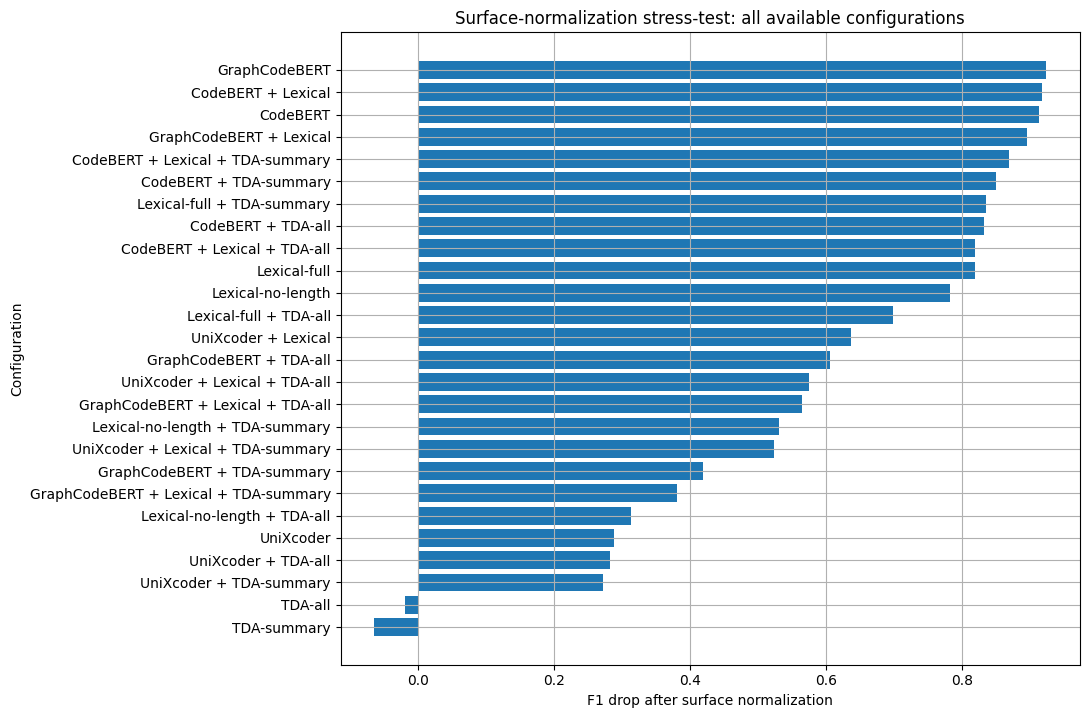

Saved: /kaggle/working/oedingen_lr_only_results/figures/surface_normalization_stress_all_available_configs.png


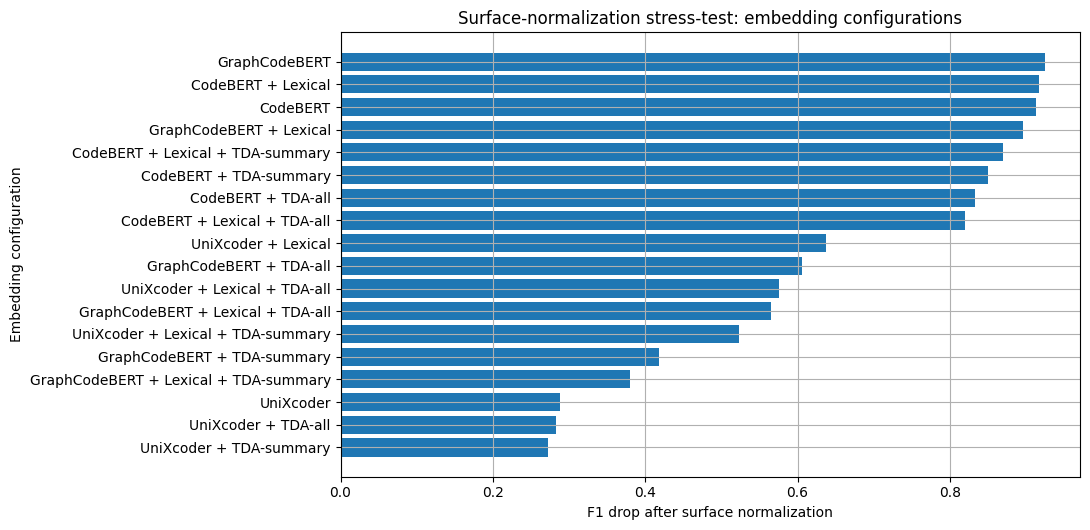

Saved: /kaggle/working/oedingen_lr_only_results/figures/surface_normalization_stress_embedding_configs.png


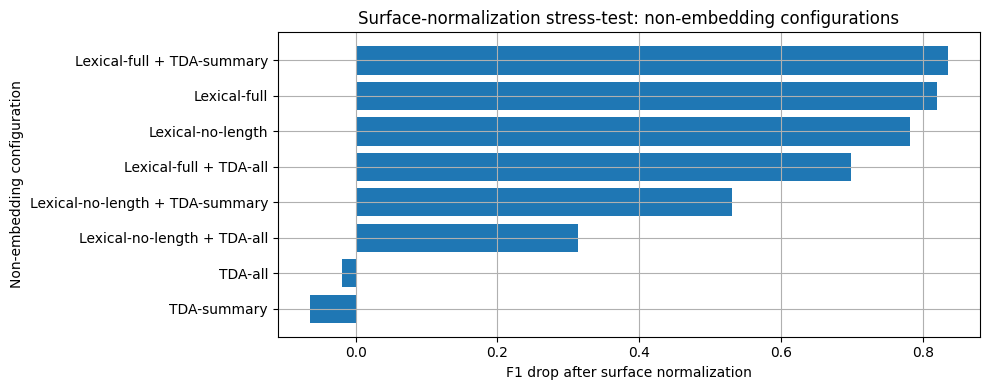

Saved: /kaggle/working/oedingen_lr_only_results/figures/surface_normalization_stress_non_embedding.png


In [30]:

plot_df = syntax_stress_all.sort_values("f1_drop", ascending=True)
plt.figure(figsize=(11, max(5, len(plot_df) * 0.28)))
plt.barh(plot_df["config"], plot_df["f1_drop"])
plt.xlabel("F1 drop after surface normalization")
plt.ylabel("Configuration")
plt.title("Surface-normalization stress-test: all available configurations")
plt.tight_layout()
fig_path = FIGURE_DIR / "surface_normalization_stress_all_available_configs.png"
plt.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)

if len(syntax_stress_embedding):
    plot_df = syntax_stress_embedding.sort_values("f1_drop", ascending=True)
    plt.figure(figsize=(11, max(5, len(plot_df) * 0.30)))
    plt.barh(plot_df["config"], plot_df["f1_drop"])
    plt.xlabel("F1 drop after surface normalization")
    plt.ylabel("Embedding configuration")
    plt.title("Surface-normalization stress-test: embedding configurations")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "surface_normalization_stress_embedding_configs.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)

if len(syntax_stress_non_embedding):
    plot_df = syntax_stress_non_embedding.sort_values("f1_drop", ascending=True)
    plt.figure(figsize=(10, max(4, len(plot_df) * 0.35)))
    plt.barh(plot_df["config"], plot_df["f1_drop"])
    plt.xlabel("F1 drop after surface normalization")
    plt.ylabel("Non-embedding configuration")
    plt.title("Surface-normalization stress-test: non-embedding configurations")
    plt.tight_layout()
    fig_path = FIGURE_DIR / "surface_normalization_stress_non_embedding.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)


## 18. Calibration and error analysis

In [31]:

# Calibration for the best final model.
best_cfg = name_lookup[best_config_name]
X_best = combine_blocks(best_cfg.blocks)
base_model = make_model(best_cfg, seed=RANDOM_SEED)
base_model.fit(X_best[train_idx], labels[train_idx])
raw_val_prob = predict_proba_safe(base_model, X_best[val_idx])
raw_test_prob = predict_proba_safe(base_model, X_best[test_idx])

# Platt-style sigmoid calibration on validation data.
try:
    calibrated = CalibratedClassifierCV(base_model, method="sigmoid", cv="prefit")
    calibrated.fit(X_best[val_idx], labels[val_idx])
    cal_test_prob = predict_proba_safe(calibrated, X_best[test_idx])
except Exception as exc:
    print("Calibration failed; falling back to raw probabilities", exc)
    cal_test_prob = raw_test_prob

calibration_results = pd.DataFrame([
    {"config": best_config_name, "variant": "raw", "brier": brier_score_loss(labels[test_idx], raw_test_prob), "f1": f1_score(labels[test_idx], (raw_test_prob >= 0.5).astype(int))},
    {"config": best_config_name, "variant": "calibrated", "brier": brier_score_loss(labels[test_idx], cal_test_prob), "f1": f1_score(labels[test_idx], (cal_test_prob >= 0.5).astype(int))},
])
calibration_results.to_csv(TABLE_DIR / "calibration_results.csv", index=False)
calibration_results

,config,variant,brier,f1
0,ADA + Lexical,raw,0.024675,0.968709
1,ADA + Lexical,calibrated,0.023186,0.968709


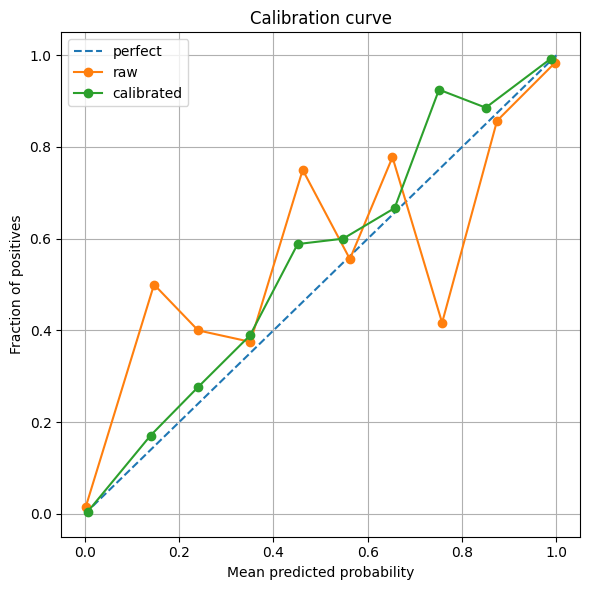

Saved: /kaggle/working/oedingen_lr_only_results/figures/calibration_curve_best_model.png


In [32]:

try:
    frac_pos, mean_pred = calibration_curve(labels[test_idx], raw_test_prob, n_bins=10)
    frac_pos_cal, mean_pred_cal = calibration_curve(labels[test_idx], cal_test_prob, n_bins=10)
    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="perfect")
    plt.plot(mean_pred, frac_pos, marker="o", label="raw")
    plt.plot(mean_pred_cal, frac_pos_cal, marker="o", label="calibrated")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration curve")
    plt.legend()
    plt.tight_layout()
    fig_path = FIGURE_DIR / "calibration_curve_best_model.png"
    plt.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", fig_path)
except Exception as exc:
    print("Could not plot calibration curve:", exc)

In [33]:
df = pd.read_json(sample_path, lines=True)

In [34]:

pred = (raw_test_prob >= 0.5).astype(int)
errors = df.iloc[test_idx].copy().reset_index(drop=False).rename(columns={"index": "row_index"})
errors["true_label"] = labels[test_idx]
errors["pred_label"] = pred
errors["prob_ai"] = raw_test_prob
errors["abs_margin"] = np.abs(raw_test_prob - 0.5)
errors["is_error"] = errors["true_label"] != errors["pred_label"]

false_positives = errors[(errors["true_label"] == 0) & (errors["pred_label"] == 1)].copy()
false_negatives = errors[(errors["true_label"] == 1) & (errors["pred_label"] == 0)].copy()
uncertain_cases = errors.sort_values("abs_margin").head(100).copy()

errors.to_csv(TABLE_DIR / "test_predictions_with_errors.csv", index=False)
false_positives.to_csv(TABLE_DIR / "false_positives.csv", index=False)
false_negatives.to_csv(TABLE_DIR / "false_negatives.csv", index=False)
uncertain_cases.to_csv(TABLE_DIR / "uncertain_cases.csv", index=False)

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))
print("Uncertain cases saved:", len(uncertain_cases))

False positives: 34
False negatives: 37
Uncertain cases saved: 100


## 19. Manifest and zipped output

In [40]:

manifest = {
    "notebook": "Oedingen LR-only complete ablation with cached embeddings",
    "created_at_unix": time.time(),
    "sample_path": str(sample_path),
    "n_rows": int(len(df)),
    "n_leakage_groups": int(df["leakage_group_id"].nunique()),
    "label_counts": {str(k): int(v) for k, v in Counter(labels).items()},
    "source_counts": {str(k): int(v) for k, v in df["source"].value_counts().items()},
    "available_embeddings": list(available_embeddings),
    "embedding_sources": embedding_sources,
    "n_configurations": len(configs),
    "configurations": [{"name": c.name, "blocks": list(c.blocks), "model_type": c.model_type, "family": c.family} for c in configs],
    "best_test_config": best_config_name,
    "classifier": "Logistic Regression only",
    "allow_embedding_generation": bool(ALLOW_EMBEDDING_GENERATION),
    "repeated_splits": REPEATED_SPLITS,
    "bootstrap_rounds": BOOTSTRAP_ROUNDS,
    "important_tables": [
        "validation_results_all_configs.csv",
        "test_results_all_configs.csv",
        "paired_tda_ablation_results.csv",
        "tda_feature_volume_results.csv",
        "hard_case_rescue_analysis.csv",
        "surface_normalization_stress_all_available_configs.csv",
        "surface_normalization_stress_embedding_configs.csv",
        "surface_normalization_stress_non_embedding.csv",
        "repeated_group_split_summary.csv",
        "source_heldout_results.csv",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")

archive_path = shutil.make_archive(str(OUTPUT_DIR), "zip", root_dir=OUTPUT_DIR)
print("Manifest saved:", OUTPUT_DIR / "manifest.json")
print("Archive saved:", archive_path)


Manifest saved: /kaggle/working/oedingen_lr_only_results/manifest.json
Archive saved: /kaggle/working/oedingen_lr_only_results.zip
